<a href="https://colab.research.google.com/github/ssk-algoverse/sae-binding/blob/main/circuit/Analyse-Circuit-Sebastian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import torch
from huggingface_hub import hf_hub_download
from transformer_lens import HookedTransformer, HookedTransformerConfig, utils, ActivationCache
import numpy as np
import pandas as pd
import ast
from torch.utils.data import Dataset, DataLoader
import torch
from functools import partial
import circuitsvis as cv
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import plotly.express as px
import re
import einops
import plotly.graph_objects as go
from jaxtyping import Float, Int
from plotly.subplots import make_subplots
from torch import Tensor
from rich import print as rprint
from rich.table import Column, Table
from IPython.display import HTML, display
from tqdm import tqdm

# Plotting Utils

In [54]:
def to_numpy(tensor):
    """
    Helper function to convert a tensor to a numpy array. Also works on lists, tuples, and numpy arrays.
    """
    if isinstance(tensor, np.ndarray):
        return tensor
    elif isinstance(tensor, (list, tuple)):
        array = np.array(tensor)
        return array
    elif isinstance(tensor, (torch.Tensor, torch.nn.parameter.Parameter)):
        return tensor.detach().cpu().numpy()
    elif isinstance(tensor, (int, float, bool, str)):
        return np.array(tensor)
    else:
        raise ValueError(f"Input to to_numpy has invalid type: {type(tensor)}")


# ! GENERIC PLOTTING FUNCTIONS

update_layout_set = {
    "xaxis_range",
    "yaxis_range",
    "hovermode",
    "xaxis_title",
    "yaxis_title",
    "colorbar",
    "colorscale",
    "coloraxis",
    "title_x",
    "bargap",
    "bargroupgap",
    "xaxis_tickformat",
    "yaxis_tickformat",
    "title_y",
    "legend_title_text",
    "xaxis_showgrid",
    "xaxis_gridwidth",
    "xaxis_gridcolor",
    "yaxis_showgrid",
    "yaxis_gridwidth",
    "yaxis_gridcolor",
    "showlegend",
    "xaxis_tickmode",
    "yaxis_tickmode",
    "margin",
    "xaxis_visible",
    "yaxis_visible",
    "bargap",
    "bargroupgap",
    "coloraxis_showscale",
    "xaxis_tickangle",
    "yaxis_scaleanchor",
    "xaxis_tickfont",
    "yaxis_tickfont",
}

update_traces_set = {"textposition"}


def imshow(tensor: torch.Tensor, renderer=None, **kwargs):
    kwargs_post = {k: v for k, v in kwargs.items() if k in update_layout_set}
    kwargs_pre = {k: v for k, v in kwargs.items() if k not in update_layout_set}
    if ("size" in kwargs_pre) or ("shape" in kwargs_pre):
        size = kwargs_pre.pop("size", None) or kwargs_pre.pop("shape", None)
        kwargs_pre["height"], kwargs_pre["width"] = size  # type: ignore
    facet_labels = kwargs_pre.pop("facet_labels", None)
    border = kwargs_pre.pop("border", False)
    return_fig = kwargs_pre.pop("return_fig", False)
    text = kwargs_pre.pop("text", None)
    xaxis_tickangle = kwargs_post.pop("xaxis_tickangle", None)
    # xaxis_tickfont = kwargs_post.pop("xaxis_tickangle", None)
    static = kwargs_pre.pop("static", False)
    if "color_continuous_scale" not in kwargs_pre:
        kwargs_pre["color_continuous_scale"] = "RdBu"
    if "color_continuous_midpoint" not in kwargs_pre:
        kwargs_pre["color_continuous_midpoint"] = 0.0
    if "margin" in kwargs_post and isinstance(kwargs_post["margin"], int):
        kwargs_post["margin"] = dict.fromkeys(list("tblr"), kwargs_post["margin"])
    fig = px.imshow(to_numpy(tensor), **kwargs_pre).update_layout(**kwargs_post)
    if facet_labels:
        # Weird thing where facet col wrap means labels are in wrong order
        if "facet_col_wrap" in kwargs_pre:
            facet_labels = reorder_list_in_plotly_way(facet_labels, kwargs_pre["facet_col_wrap"])
        for i, label in enumerate(facet_labels):
            fig.layout.annotations[i]["text"] = label  # type: ignore
    if border:
        fig.update_xaxes(showline=True, linewidth=1, linecolor="black", mirror=True)
        fig.update_yaxes(showline=True, linewidth=1, linecolor="black", mirror=True)
    if text:
        if tensor.ndim == 2:
            # if 2D, then we assume text is a list of lists of strings
            assert isinstance(text[0], list)
            assert isinstance(text[0][0], str)
            text = [text]
        else:
            # if 3D, then text is either repeated for each facet, or different
            assert isinstance(text[0], list)
            if isinstance(text[0][0], str):
                text = [text for _ in range(len(fig.data))]
        for i, _text in enumerate(text):
            fig.data[i].update(text=_text, texttemplate="%{text}", textfont={"size": 12})
    # Very hacky way of fixing the fact that updating layout with xaxis_* only applies to first facet by default
    if xaxis_tickangle is not None:
        n_facets = 1 if tensor.ndim == 2 else tensor.shape[0]
        for i in range(1, 1 + n_facets):
            xaxis_name = "xaxis" if i == 1 else f"xaxis{i}"
            fig.layout[xaxis_name]["tickangle"] = xaxis_tickangle  # type: ignore
    return fig if return_fig else fig.show(renderer=renderer, config={"staticPlot": static})


def reorder_list_in_plotly_way(L: list, col_wrap: int):
    """
    Helper function, because Plotly orders figures in an annoying way when there's column wrap.
    """
    L_new = []
    while len(L) > 0:
        L_new.extend(L[-col_wrap:])
        L = L[:-col_wrap]
    return L_new


def line(y: torch.Tensor | list, renderer=None, **kwargs):
    """
    Edit to this helper function, allowing it to take args in update_layout (e.g. yaxis_range).
    """
    kwargs_post = {k: v for k, v in kwargs.items() if k in update_layout_set}
    kwargs_pre = {k: v for k, v in kwargs.items() if k not in update_layout_set}
    if ("size" in kwargs_pre) or ("shape" in kwargs_pre):
        size = kwargs_pre.pop("size", None) or kwargs_pre.pop("shape", None)
        kwargs_pre["height"], kwargs_pre["width"] = size  # type: ignore
    return_fig = kwargs_pre.pop("return_fig", False)
    if "margin" in kwargs_post and isinstance(kwargs_post["margin"], int):
        kwargs_post["margin"] = dict.fromkeys(list("tblr"), kwargs_post["margin"])
    if "xaxis_tickvals" in kwargs_pre:
        tickvals = kwargs_pre.pop("xaxis_tickvals")
        kwargs_post["xaxis"] = dict(
            tickmode="array",
            tickvals=kwargs_pre.get("x", np.arange(len(tickvals))),
            ticktext=tickvals,
        )
    if "hovermode" not in kwargs_post:
        kwargs_post["hovermode"] = "x unified"
    hovertext = kwargs_pre.pop("hovertext", None)
    if "use_secondary_yaxis" in kwargs_pre and kwargs_pre["use_secondary_yaxis"]:
        del kwargs_pre["use_secondary_yaxis"]
        if "labels" in kwargs_pre:
            labels: dict = kwargs_pre.pop("labels")
            kwargs_post["yaxis_title_text"] = labels.get("y1", None)
            kwargs_post["yaxis2_title_text"] = labels.get("y2", None)
            kwargs_post["xaxis_title_text"] = labels.get("x", None)
        for k in ["title", "template", "width", "height"]:
            if k in kwargs_pre:
                kwargs_post[k] = kwargs_pre.pop(k)
        fig = make_subplots(specs=[[{"secondary_y": True}]]).update_layout(**kwargs_post)
        y0 = to_numpy(y[0])
        y1 = to_numpy(y[1])
        x0, x1 = kwargs_pre.pop("x", [np.arange(len(y0)), np.arange(len(y1))])
        name0, name1 = kwargs_pre.pop("names", ["yaxis1", "yaxis2"])
        fig.add_trace(go.Scatter(y=y0, x=x0, name=name0), secondary_y=False)
        fig.add_trace(go.Scatter(y=y1, x=x1, name=name1), secondary_y=True)
    else:
        y = (
            list(map(to_numpy, y))
            if isinstance(y, list) and not (isinstance(y[0], int) or isinstance(y[0], float))
            else to_numpy(y)
        )  # type: ignore
        names = kwargs_pre.pop("names", None)
        fig = px.line(y=y, **kwargs_pre).update_layout(**kwargs_post)
        if names is not None:
            fig.for_each_trace(lambda trace: trace.update(name=names.pop(0)))
    if hovertext is not None:
        ht = fig.data[0].hovertemplate
        fig.for_each_trace(lambda trace: trace.update(hovertext=hovertext, hovertemplate="%{hovertext}<br>" + ht))

    return fig if return_fig else fig.show(renderer=renderer)


def scatter(x, y, renderer=None, **kwargs):
    x = to_numpy(x)
    y = to_numpy(y)
    add_line = None
    if "add_line" in kwargs:
        add_line = kwargs.pop("add_line")
    kwargs_post = {k: v for k, v in kwargs.items() if k in update_layout_set}
    kwargs_traces = {k: v for k, v in kwargs.items() if k in update_traces_set}
    kwargs_pre = {k: v for k, v in kwargs.items() if k not in (update_layout_set | update_traces_set)}
    if ("size" in kwargs_pre) or ("shape" in kwargs_pre):
        size = kwargs_pre.pop("size", None) or kwargs_pre.pop("shape", None)
        kwargs_pre["height"], kwargs_pre["width"] = size  # type: ignore
    return_fig = kwargs_pre.pop("return_fig", False)
    facet_labels = kwargs_pre.pop("facet_labels", None)
    if "margin" in kwargs_post and isinstance(kwargs_post["margin"], int):
        kwargs_post["margin"] = dict.fromkeys(list("tblr"), kwargs_post["margin"])
    fig = px.scatter(y=y, x=x, **kwargs_pre).update_layout(**kwargs_post)
    if add_line is not None:
        xrange = fig.layout.xaxis.range or [x.min(), x.max()]  # type: ignore
        yrange = fig.layout.yaxis.range or [y.min(), y.max()]  # type: ignore
        add_line = add_line.replace(" ", "")
        if add_line in ["x=y", "y=x"]:
            fig.add_trace(go.Scatter(mode="lines", x=xrange, y=xrange, showlegend=False))
        elif re.match("(x|y)=", add_line):
            try:
                c = float(add_line.split("=")[1])
            except:
                raise ValueError(
                    f"Unrecognized add_line: {add_line}. Please use either 'x=y' or 'x=c' or 'y=c' for some float c."
                )
            x, y = ([c, c], yrange) if add_line[0] == "x" else (xrange, [c, c])
            fig.add_trace(go.Scatter(mode="lines", x=x, y=y, showlegend=False))
        else:
            raise ValueError(
                f"Unrecognized add_line: {add_line}. Please use either 'x=y' or 'x=c' or 'y=c' for some float c."
            )
    if facet_labels:
        for i, label in enumerate(facet_labels):
            fig.layout.annotations[i]["text"] = label  # type: ignore
    fig.update_traces(**kwargs_traces)
    return fig if return_fig else fig.show(renderer=renderer)


def bar(tensor, renderer=None, **kwargs):
    """ """
    if isinstance(tensor, list):
        if isinstance(tensor[0], torch.Tensor):
            arr = [to_numpy(tn) for tn in tensor]
        elif isinstance(tensor[0], list):
            arr = [np.array(tn) for tn in tensor]
        else:
            arr = np.array(tensor)
    else:
        arr = to_numpy(tensor)
    kwargs_post = {k: v for k, v in kwargs.items() if k in update_layout_set}
    kwargs_pre = {k: v for k, v in kwargs.items() if k not in update_layout_set}
    return_fig = kwargs_pre.pop("return_fig", False)
    names = kwargs_pre.pop("names", None)
    if "hovermode" not in kwargs_post:
        kwargs_post["hovermode"] = "x unified"
    if "margin" in kwargs_post and isinstance(kwargs_post["margin"], int):
        kwargs_post["margin"] = dict.fromkeys(list("tblr"), kwargs_post["margin"])
    fig = px.bar(y=arr, **kwargs_pre).update_layout(**kwargs_post)
    if names is not None:
        for i in range(len(fig.data)):
            fig.data[i]["name"] = names[i // 2 if "marginal" in kwargs_pre else i]
    return fig if return_fig else fig.show(renderer=renderer)


def hist(tensor, renderer=None, **kwargs):
    kwargs_post = {k: v for k, v in kwargs.items() if k in update_layout_set}
    kwargs_pre = {k: v for k, v in kwargs.items() if k not in update_layout_set}
    # draw = kwargs_pre.pop("draw", True)
    # static = kwargs_pre.pop("static", False)
    return_fig = kwargs_pre.pop("return_fig", False)
    if isinstance(tensor, list):
        if isinstance(tensor[0], torch.Tensor):
            arr = [to_numpy(tn) for tn in tensor]
        elif isinstance(tensor[0], list):
            arr = [np.array(tn) for tn in tensor]
        else:
            arr = np.array(tensor)
    else:
        arr = to_numpy(tensor)
    if "modebar_add" not in kwargs_post:
        kwargs_post["modebar_add"] = [
            "drawline",
            "drawopenpath",
            "drawclosedpath",
            "drawcircle",
            "drawrect",
            "eraseshape",
        ]
    add_mean_line = kwargs_pre.pop("add_mean_line", False)
    names = kwargs_pre.pop("names", None)
    if "barmode" not in kwargs_post:
        kwargs_post["barmode"] = "overlay"
    if "bargap" not in kwargs_post:
        kwargs_post["bargap"] = 0.0
    if "margin" in kwargs_post and isinstance(kwargs_post["margin"], int):
        kwargs_post["margin"] = dict.fromkeys(list("tblr"), kwargs_post["margin"])
    if "hovermode" not in kwargs_post:
        kwargs_post["hovermode"] = "x unified"
    if "autosize" not in kwargs_post:
        kwargs_post["autosize"] = False

    # If `arr` has a list of arrays, then just doing px.histogram doesn't work annoyingly enough
    # This is janky, even for my functions!
    if isinstance(arr, list) and isinstance(arr[0], np.ndarray):
        assert "marginal" not in kwargs_pre, "Can't use `marginal` with a list of arrays"
        for thing_to_move_from_pre_to_post in ["title", "template", "height", "width", "labels"]:
            if thing_to_move_from_pre_to_post in kwargs_pre:
                kwargs_post[thing_to_move_from_pre_to_post] = kwargs_pre.pop(thing_to_move_from_pre_to_post)
        if "labels" in kwargs_post:
            kwargs_post["xaxis_title_text"] = kwargs_post["labels"].get("x", "")
            kwargs_post["yaxis_title_text"] = kwargs_post["labels"].get("y", "")
            del kwargs_post["labels"]
        fig = go.Figure(layout=go.Layout(**kwargs_post))
        if "nbins" in kwargs_pre:
            kwargs_pre["nbinsx"] = int(kwargs_pre.pop("nbins"))
        for x in arr:
            fig.add_trace(go.Histogram(x=x, name=names.pop(0) if names is not None else None, **kwargs_pre))
    else:
        fig = px.histogram(x=arr, **kwargs_pre).update_layout(**kwargs_post)
        if names is not None:
            for i in range(len(fig.data)):
                fig.data[i]["name"] = names[i // 2 if "marginal" in kwargs_pre else i]

    assert isinstance(arr, (np.ndarray, Tensor))

    if add_mean_line:
        if arr.ndim == 1:
            fig.add_vline(
                x=arr.mean(),
                line_width=3,
                line_dash="dash",
                line_color="black",
                annotation_text=f"Mean = {arr.mean():.3f}",
                annotation_position="top",
            )
        elif arr.ndim == 2:
            for i in range(arr.shape[0]):
                fig.add_vline(
                    x=arr[i].mean(),
                    line_width=3,
                    line_dash="dash",
                    line_color="black",
                    annotation_text=f"Mean = {arr.mean():.3f}",
                    annotation_position="top",
                )
    return fig if return_fig else fig.show(renderer=renderer)


# ! PLOTTING FUNCTIONS FOR PART 2: INTRO TO MECH INTERP


def plot_comp_scores(
    model, comp_scores, title: str = "", baseline: torch.Tensor | None = None, filename: str | None = None
):
    fig = px.imshow(
        to_numpy(comp_scores),
        y=[f"L0H{h}" for h in range(model.cfg.n_heads)],
        x=[f"L1H{h}" for h in range(model.cfg.n_heads)],
        labels={"x": "Layer 1", "y": "Layer 0"},
        title=title,
        color_continuous_scale="RdBu" if baseline is not None else "Blues",
        color_continuous_midpoint=baseline if baseline is not None else None,
        zmin=None if baseline is not None else 0.0,
        width=550,
        height=450,
    )
    fig.show()
    if filename is not None:
        fig.write_html(filename)


def convert_tokens_to_string(model, tokens, batch_index=0):
    """
    Helper function to convert tokens into a list of strings, for printing.
    """
    if len(tokens.shape) == 2:
        tokens = tokens[batch_index]
    return [f"|{model.tokenizer.decode(tok)}|_{c}" for (c, tok) in enumerate(tokens)]


def plot_logit_attribution(model, logit_attr: torch.Tensor, tokens: torch.Tensor, title: str = "", filename: str | None = None):
    tokens = tokens.squeeze()
    y_labels = convert_tokens_to_string(model, tokens[:-1])
    x_labels = ["Direct"] + [f"L{l}H{h}" for l in range(model.cfg.n_layers) for h in range(model.cfg.n_heads)]
    fig = imshow(
        to_numpy(logit_attr),  # type: ignore
        x=x_labels,
        y=y_labels,
        labels={"x": "Term", "y": "Position", "color": "logit"},
        title=title if title else None,
        height=100 + (30 if title else 0) + 15 * len(y_labels),
        width=24 * len(x_labels),
        return_fig=True,
    )
    fig.show()
    if filename is not None:
        fig.write_html(filename)


# ! PLOTTING FUNCTIONS FOR PART 4: BALANCED BRACKET CLASSIFICATION

color_discrete_map = dict(
    zip(
        ["both failures", "just neg failure", "balanced", "just total elevation failure"],
        px.colors.qualitative.D3,
    )
)
# names = ["balanced", "just total elevation failure", "just neg failure", "both failures"]
# colors = ['#2CA02C', '#1c96eb', '#b300ff', '#ff4800']
# color_discrete_map = dict(zip(names, colors))


def plot_failure_types_scatter(
    unbalanced_component_1: Float[Tensor, "batch"],
    unbalanced_component_2: Float[Tensor, "batch"],
    failure_types_dict: dict[str, Float[Tensor, "batch"]],
    data,
    filename: str | None = None,
):
    failure_types = np.full(len(unbalanced_component_1), "", dtype=np.dtype("U32"))
    for name, mask in failure_types_dict.items():
        failure_types = np.where(to_numpy(mask), name, failure_types)
    failures_df = pd.DataFrame(
        {
            "Head 2.0 contribution": to_numpy(unbalanced_component_1),
            "Head 2.1 contribution": to_numpy(unbalanced_component_2),
            "Failure type": to_numpy(failure_types),
        }
    )[data.starts_open.tolist()]
    fig = px.scatter(
        failures_df,
        color_discrete_map=color_discrete_map,
        x="Head 2.0 contribution",
        y="Head 2.1 contribution",
        color="Failure type",
        title="h20 vs h21 for different failure types",
        template="simple_white",
        height=600,
        width=800,
        # category_orders={"color": failure_types_dict.keys()},
    ).update_traces(marker_size=4)
    fig.show()
    if filename is not None:
        fig.write_html(filename)


def plot_contribution_vs_open_proportion(
    unbalanced_component: Float[Tensor, "batch"],
    title: str,
    failure_types_dict: dict,
    data,
    filename: str | None = None,
):
    failure_types = np.full(len(unbalanced_component), "", dtype=np.dtype("U32"))
    for name, mask in failure_types_dict.items():
        failure_types = np.where(to_numpy(mask), name, failure_types)
    fig = (
        px.scatter(
            x=to_numpy(data.open_proportion),
            y=to_numpy(unbalanced_component),
            color=failure_types,
            color_discrete_map=color_discrete_map,
            title=title,
            template="simple_white",
            height=500,
            width=800,
            labels={"x": "Open-proportion", "y": "Head contribution"},
        )
        .update_traces(marker_size=4, opacity=0.5)
        .update_layout(legend_title_text="Failure type")
    )
    fig.show()
    if filename is not None:
        fig.write_html(filename)


def mlp_attribution_scatter(
    out_by_component_in_pre_20_unbalanced_dir: Float[Tensor, "comp batch"],
    data,
    failure_types_dict: dict,
    filenames: list[str] | None = None,
) -> None:
    failure_types = np.full(out_by_component_in_pre_20_unbalanced_dir.shape[-1], "", dtype=np.dtype("U32"))
    for name, mask in failure_types_dict.items():
        failure_types = np.where(to_numpy(mask), name, failure_types)
    for layer in range(2):
        mlp_output = out_by_component_in_pre_20_unbalanced_dir[3 + layer * 3]
        fig = (
            px.scatter(
                x=to_numpy(data.open_proportion[data.starts_open]),
                y=to_numpy(mlp_output[data.starts_open]),
                color_discrete_map=color_discrete_map,
                color=to_numpy(failure_types)[to_numpy(data.starts_open)],
                title=f"Amount MLP {layer} writes in unbalanced direction for Head 2.0",
                template="simple_white",
                height=500,
                width=800,
                labels={"x": "Open-proportion", "y": "Head 2.0 contribution"},
            )
            .update_traces(marker_size=4, opacity=0.5)
            .update_layout(legend_title_text="Failure type")
        )
        fig.show()
        if filenames is not None:
            assert len(filenames) == 2
            fig.write_html(filenames[layer])


def plot_neurons(
    neurons_in_unbalanced_dir: Float[Tensor, "batch neurons"],
    model,
    data,
    failure_types_dict: dict,
    layer: int,
    renderer=None,
    filename: str | None = None,
):
    failure_types = np.full(neurons_in_unbalanced_dir.shape[0], "", dtype=np.dtype("U32"))
    for name, mask in failure_types_dict.items():
        failure_types = np.where(to_numpy(mask[to_numpy(data.starts_open)]), name, failure_types)

    # Get data that can be turned into a dataframe (plotly express is sometimes easier to use with a dataframe)
    # Plot a scatter plot of all the neuron contributions, color-coded according to failure type, with slider to view neurons
    neuron_numbers = einops.repeat(t.arange(model.cfg.d_model), "n -> (s n)", s=data.starts_open.sum())
    failure_types = einops.repeat(failure_types, "s -> (s n)", n=model.cfg.d_model)
    data_open_proportion = einops.repeat(data.open_proportion[data.starts_open], "s -> (s n)", n=model.cfg.d_model)
    df = pd.DataFrame(
        {
            "Output in 2.0 direction": to_numpy(neurons_in_unbalanced_dir.flatten()),
            "Neuron number": to_numpy(neuron_numbers),
            "Open-proportion": to_numpy(data_open_proportion),
            "Failure type": failure_types,
        }
    )
    fig = (
        px.scatter(
            df,
            x="Open-proportion",
            y="Output in 2.0 direction",
            color="Failure type",
            animation_frame="Neuron number",
            title=f"Neuron contributions from layer {layer}",
            template="simple_white",
            height=800,
            width=1100,
        )
        .update_traces(marker_size=3)
        .update_layout(xaxis_range=[0, 1], yaxis_range=[-5, 5])
    )
    fig.show(renderer=renderer)
    if filename is not None:
        fig.write_html(filename)


def plot_attn_pattern(pattern: Float[Tensor, "batch head_idx seqQ seqK"], filename: str | None = None):
    fig = px.imshow(
        pattern,
        title="Estimate for avg attn probabilities when query is from '('",
        labels={
            "x": "Key tokens (avg of left & right parens)",
            "y": "Query tokens (all left parens)",
        },
        height=900,
        width=900,
        color_continuous_scale="RdBu_r",
        range_color=[0, pattern.max().item()],
    ).update_layout(
        xaxis=dict(
            tickmode="array",
            ticktext=["[start]", *[f"{i+1}" for i in range(40)], "[end]"],
            tickvals=list(range(42)),
            tickangle=0,
        ),
        yaxis=dict(
            tickmode="array",
            ticktext=["[start]", *[f"{i+1}" for i in range(40)], "[end]"],
            tickvals=list(range(42)),
        ),
    )
    fig.show()
    if filename is not None:
        fig.write_html(filename)


def hists_per_comp(
    out_by_component_in_unbalanced_dir: Float[Tensor, "component batch"],
    data,
    xaxis_range=(-1, 1),
    filename: str | None = None,
):
    """
    Plots the contributions in the unbalanced direction, as supplied by the `out_by_component_in_unbalanced_dir` tensor.
    """
    titles = {
        (1, 1): "embeddings",
        (2, 1): "head 0.0",
        (2, 2): "head 0.1",
        (2, 3): "mlp 0",
        (3, 1): "head `1.0`",
        (3, 2): "head `1.1`",
        (3, 3): "mlp 1",
        (4, 1): "head 2.0",
        (4, 2): "head 2.1",
        (4, 3): "mlp 2",
    }
    n_layers = out_by_component_in_unbalanced_dir.shape[0] // 3
    fig = make_subplots(rows=n_layers + 1, cols=3)
    for ((row, col), title), in_dir in zip(titles.items(), out_by_component_in_unbalanced_dir):
        fig.add_trace(
            go.Histogram(
                x=to_numpy(in_dir[data.isbal]),
                name="Balanced",
                marker_color="blue",
                opacity=0.5,
                legendgroup="1",
                showlegend=title == "embeddings",
            ),
            row=row,
            col=col,
        )
        fig.add_trace(
            go.Histogram(
                x=to_numpy(in_dir[~data.isbal]),
                name="Unbalanced",
                marker_color="red",
                opacity=0.5,
                legendgroup="2",
                showlegend=title == "embeddings",
            ),
            row=row,
            col=col,
        )
        fig.update_xaxes(title_text=title, row=row, col=col, range=xaxis_range)
    fig.update_layout(
        width=1200,
        height=250 * (n_layers + 1),
        barmode="overlay",
        legend=dict(yanchor="top", y=0.92, xanchor="left", x=0.4),
        title="Histograms of component significance",
    )
    fig.show()
    if filename is not None:
        fig.write_html(filename)


def plot_loss_difference(log_probs, rep_str, seq_len, filename: str | None = None):
    fig = px.line(
        to_numpy(log_probs),
        hover_name=rep_str[1:],
        title=f"Per token log prob on correct token, for sequence of length {seq_len}*2 (repeated twice)",
        labels={"index": "Sequence position", "value": "Log prob"},
    ).update_layout(showlegend=False, hovermode="x unified")
    fig.add_vrect(x0=0, x1=seq_len - 0.5, fillcolor="red", opacity=0.2, line_width=0)
    fig.add_vrect(x0=seq_len - 0.5, x1=2 * seq_len - 1, fillcolor="green", opacity=0.2, line_width=0)
    fig.show()
    if filename is not None:
        fig.write_html(filename)


# Setup

In [55]:
from huggingface_hub import hf_hub_download

REPO_ID = "sebastianhoenig/2L2H_Final"
FILENAME = "D256_L2_H2_attnOnly1_lr5.0e-04_wd0.01.pt"

weights_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

In [56]:
REPO_ID = "sojup/entity_binding_test"
FILENAME = "id_to_entity.csv"

id_mapping_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

In [57]:
E = 100
T = 10
D_VOCAB = E + T + 3
N_LAYERS = 2
HEADS = 2
d_model = 256
n_ctx   = 64

def build_model(n_layers: int, n_heads: int) -> HookedTransformer:
    if d_model % n_heads != 0:
        return None
    d_head = d_model // n_heads

    cfg = HookedTransformerConfig(
        n_layers=n_layers,
        n_heads=n_heads,
        d_model=d_model,
        d_head=d_head,
        n_ctx=n_ctx,
        d_vocab=D_VOCAB,
        d_vocab_out=E,
        attn_only=True,
        normalization_type="LN",
        positional_embedding_type="rotary",
    )
    return HookedTransformer(cfg)

model = build_model(N_LAYERS, HEADS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Load the model
pretrained_weights = torch.load(weights_path, map_location=device, weights_only=True)
state_dict = pretrained_weights["model"]
model.load_state_dict(state_dict)

print("Model loaded successfully.")

# need this for attention patching later
model.cfg.use_attn_result = True

Moving model to device:  cpu
Model loaded successfully.


In [58]:
id_mapping_df = pd.read_csv(id_mapping_path)
id_to_entity = dict(zip(id_mapping_df['id'], id_mapping_df['name']))

In [59]:
id_to_entity[100] = 'loves'
id_to_entity[101] = 'works with'
id_to_entity[102] = 'interacts with'
id_to_entity[103] = 'lives with'
id_to_entity[104] = 'has a grudge against'
id_to_entity[105] = 'is interested in'
id_to_entity[106] = 'plays with'
id_to_entity[107] = 'goes to school with'
id_to_entity[108] = 'is jealous of'
id_to_entity[109] = 'wants'

In [60]:
id_to_entity_rev = {v: k for k, v in id_to_entity.items()}

In [61]:
class EntityBindingDataset(Dataset):
    def __init__(self, dataframe, parse_tokens_if_str=True):
        self.df = dataframe.reset_index(drop=True)
        self.parse_tokens_if_str = parse_tokens_if_str

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        seq = row["tokens"]
        tokens = torch.tensor(seq, dtype=torch.long)
        label  = torch.tensor(int(row["label"]), dtype=torch.long)
        return tokens, label

In [62]:
from datasets import load_dataset

dataset = load_dataset("sojup/entity_binding", split="test")

In [63]:
test_df = dataset.to_pandas()
test_dataset = EntityBindingDataset(test_df)

In [64]:
example, label = test_dataset[0]
example, label, [id_to_entity[i.item()] for i in example], id_to_entity[label.item()]

(tensor([ 10, 104,   1, 110,  20, 103,  30, 110,  70, 105,  37, 110,  30, 100,
          24, 110, 105,  70, 111]),
 tensor(37),
 ['Jeffery',
  'has a grudge against',
  'Angel',
  ',',
  'Linda',
  'lives with',
  'Lindsay',
  ',',
  'Jason',
  'is interested in',
  'Christine',
  ',',
  'Lindsay',
  'loves',
  'Susan',
  ',',
  'is interested in',
  'Jason',
  '?'],
 'Christine')

In [65]:
token_prompt = test_dataset[0][0]
token_prompt[4] = 70
logits, cache = model.run_with_cache(token_prompt)
probs = torch.softmax(logits[0, -1, :], dim=-1)
print([id_to_entity[i.item()] for i in token_prompt], id_to_entity[label.item()])
for i, idx2 in enumerate(torch.topk(probs, 5).indices.tolist()):
  print(f"{id_to_entity[idx2]} {torch.topk(probs, 5).values.tolist()[i]}")
print(f"Correct label: {id_to_entity[test_dataset[0][1].item()]}\n\n")

['Jeffery', 'has a grudge against', 'Angel', ',', 'Jason', 'lives with', 'Lindsay', ',', 'Jason', 'is interested in', 'Christine', ',', 'Lindsay', 'loves', 'Susan', ',', 'is interested in', 'Jason', '?'] Christine
Christine 1.0
James 4.275214848803444e-09
Lindsay 3.5964131672727717e-09
Jesse 3.531160031045033e-09
Jeffery 3.3041844815784316e-09
Correct label: Christine




In [66]:
token_prompt = test_dataset[0][0]
token_prompt[4] = 70
token_prompt[5] = 105
logits, cache = model.run_with_cache(token_prompt)
probs = torch.softmax(logits[0, -1, :], dim=-1)
print([id_to_entity[i.item()] for i in token_prompt], id_to_entity[label.item()])
for i, idx2 in enumerate(torch.topk(probs, 5).indices.tolist()):
  print(f"{id_to_entity[idx2]} {torch.topk(probs, 5).values.tolist()[i]}")
print(f"Correct label: {id_to_entity[test_dataset[0][1].item()]}\n\n")

['Jeffery', 'has a grudge against', 'Angel', ',', 'Jason', 'is interested in', 'Lindsay', ',', 'Jason', 'is interested in', 'Christine', ',', 'Lindsay', 'loves', 'Susan', ',', 'is interested in', 'Jason', '?'] Christine
Lindsay 0.8137910962104797
Christine 0.18595550954341888
Leonard 1.8355045540374704e-05
Lisa 1.6767120541771874e-05
Whitney 1.2404872904880904e-05
Correct label: Christine




In [67]:
token_prompt = test_dataset[0][0]
token_prompt[4] = 70
token_prompt[5] = 105
token_prompt[9] = 106
logits, cache = model.run_with_cache(token_prompt)
probs = torch.softmax(logits[0, -1, :], dim=-1)
print([id_to_entity[i.item()] for i in token_prompt], id_to_entity[label.item()])
for i, idx2 in enumerate(torch.topk(probs, 5).indices.tolist()):
  print(f"{id_to_entity[idx2]} {torch.topk(probs, 5).values.tolist()[i]}")
print(f"Correct label: {id_to_entity[test_dataset[0][1].item()]}\n\n")

['Jeffery', 'has a grudge against', 'Angel', ',', 'Jason', 'is interested in', 'Lindsay', ',', 'Jason', 'plays with', 'Christine', ',', 'Lindsay', 'loves', 'Susan', ',', 'is interested in', 'Jason', '?'] Christine
Lindsay 0.9999998807907104
Susan 6.7455894203760636e-09
Lisa 5.227961175080509e-09
Christine 4.714500789759768e-09
Sherri 4.622961569111794e-09
Correct label: Christine




In [68]:
token_prompt = test_dataset[0][0]
token_prompt[4] = 70
token_prompt[16] = 103
logits, cache = model.run_with_cache(token_prompt)
probs = torch.softmax(logits[0, -1, :], dim=-1)
print([id_to_entity[i.item()] for i in token_prompt], id_to_entity[label.item()])
for i, idx2 in enumerate(torch.topk(probs, 5).indices.tolist()):
  print(f"{id_to_entity[idx2]} {torch.topk(probs, 5).values.tolist()[i]}")
print(f"Correct label: {id_to_entity[test_dataset[0][1].item()]}\n\n")

['Jeffery', 'has a grudge against', 'Angel', ',', 'Jason', 'lives with', 'Lindsay', ',', 'Jason', 'is interested in', 'Christine', ',', 'Lindsay', 'loves', 'Susan', ',', 'lives with', 'Jason', '?'] Christine
Lindsay 0.9999998807907104
Susan 6.316043688059381e-09
Lisa 5.466080477134483e-09
Sherri 5.012819936922597e-09
Christine 4.691179000815282e-09
Correct label: Christine




# Following 1.4.1.1: Model & Task Setup

In [69]:
# Finding queries with the same length ... makes it easier I guess (no padding)
query_idcs = []
for i in range(37):
    if len(test_dataset[i][0]) == 19:
        query_idcs.append(i)
query_idcs

[0, 10, 13, 24, 26, 34, 35, 36]

In [70]:
clean_tokens = []
answer_tokens = []

for idx in query_idcs:
    token_prompt = test_dataset[idx][0]
    clean_tokens.append(token_prompt)
    logits, cache = model.run_with_cache(token_prompt)
    probs = torch.softmax(logits[0, -1, :], dim=-1)

    for i, idx2 in enumerate(torch.topk(probs, 2).indices.tolist()):
      print(f"{id_to_entity[idx2]} {torch.topk(probs, 2).values.tolist()[i]}")
    answer_tokens.append(torch.topk(probs, 2).indices.tolist())
    print(f"Correct label: {id_to_entity[test_dataset[idx][1].item()]}\n\n")

Christine 1.0
James 4.195916503135777e-09
Correct label: Christine


Matthew 1.0
Bryan 3.600751030674587e-09
Correct label: Matthew


Rachael 1.0
Robert 1.6276269611606442e-12
Correct label: Rachael


Jeremy 1.0
Laura 6.64993304866357e-09
Correct label: Jeremy


Andrea 1.0
Maria 6.083634485065659e-09
Correct label: Andrea


Stephen 1.0
Gabrielle 6.642935090894753e-09
Correct label: Stephen


Jason 1.0
Robert 8.098263379330284e-12
Correct label: Jason


Jessica 1.0
Melanie 5.07438713270858e-09
Correct label: Jessica




In [71]:
clean_prompts = [[id_to_entity[token.item()] for token in sublist]for sublist in clean_tokens]

In [72]:
clean_prompts[0]

['Jeffery',
 'has a grudge against',
 'Angel',
 ',',
 'Linda',
 'lives with',
 'Lindsay',
 ',',
 'Jason',
 'is interested in',
 'Christine',
 ',',
 'Lindsay',
 'loves',
 'Susan',
 ',',
 'is interested in',
 'Jason',
 '?']

In [73]:
answer_tokens = torch.tensor(answer_tokens)
answer_tokens

tensor([[37, 13],
        [25, 94],
        [83, 93],
        [42, 92],
        [35, 36],
        [77, 63],
        [51, 93],
        [31, 28]])

In [74]:
answers = [(id_to_entity[answer_tokens[i][0].item()], id_to_entity[answer_tokens[i][1].item()]) for i in range(len(answer_tokens))]

In [75]:
answers

[('Christine', 'James'),
 ('Matthew', 'Bryan'),
 ('Rachael', 'Robert'),
 ('Jeremy', 'Laura'),
 ('Andrea', 'Maria'),
 ('Stephen', 'Gabrielle'),
 ('Jason', 'Robert'),
 ('Jessica', 'Melanie')]

In [76]:
clean_tokens = torch.stack(clean_tokens, dim=0)
clean_tokens

tensor([[ 10, 104,   1, 110,  20, 103,  30, 110,  70, 105,  37, 110,  30, 100,
          24, 110, 105,  70, 111],
        [ 62, 107,  38, 110,  89, 106,   9, 110,  92, 101,  25, 110,   7, 100,
          76, 110, 101,  92, 111],
        [ 58, 108,  64, 110,  36, 103,  73, 110,  57, 101,  50, 110,  28, 104,
          83, 110, 104,  28, 111],
        [ 56, 108,  17, 110,  86, 105,  42, 110,  77, 109,  87, 110,   4, 103,
          37, 110, 105,  86, 111],
        [  3, 108,  35, 110,  32, 109,   8, 110,  34, 102,  79, 110,  53, 100,
          71, 110, 108,   3, 111],
        [ 87, 103,  96, 110,  14, 108,  91, 110,  19, 106,  61, 110,  13, 109,
          77, 110, 109,  13, 111],
        [ 30, 101,  51, 110,  15, 100,  34, 110,  65, 107,  39, 110,  84, 102,
          56, 110, 101,  30, 111],
        [ 64, 107,  85, 110,   8, 101,  29, 110,  66, 103,  31, 110,  73, 108,
          31, 110, 103,  66, 111]])

In [77]:
original_logits, cache = model.run_with_cache(clean_tokens)

In [78]:
original_logits.shape

torch.Size([8, 19, 100])

In [79]:
def logits_to_ave_logit_diff(
    logits: Float[Tensor, "batch seq d_vocab"],
    answer_tokens: Int[Tensor, "batch 2"] = answer_tokens,
    per_prompt: bool = False,
) -> Float[Tensor, "*batch"]:
    """
    Returns logit difference between the correct and incorrect answer.

    If per_prompt=True, return the array of differences rather than the average.
    """
    # Only the final logits are relevant for the answer
    final_logits: Float[Tensor, "batch d_vocab"] = logits[:, -1, :]
    # Get the logits corresponding to the indirect object / subject tokens respectively
    answer_logits: Float[Tensor, "batch 2"] = final_logits.gather(dim=-1, index=answer_tokens)
    # Find logit difference
    correct_logits, incorrect_logits = answer_logits.unbind(dim=-1)
    answer_logit_diff = correct_logits - incorrect_logits
    return answer_logit_diff if per_prompt else answer_logit_diff.mean()

In [80]:
original_per_prompt_diff = logits_to_ave_logit_diff(original_logits, answer_tokens, per_prompt=True)
print("Per prompt logit difference:", original_per_prompt_diff)
original_average_logit_diff = logits_to_ave_logit_diff(original_logits, answer_tokens)
print("Average logit difference:", original_average_logit_diff)

Per prompt logit difference: tensor([19.2892, 19.4421, 27.1439, 18.8287, 18.9177, 18.8297, 25.5394, 19.0991],
       grad_fn=<SubBackward0>)
Average logit difference: tensor(20.8862, grad_fn=<MeanBackward0>)


In [81]:
cols = [
    "Prompt",
    Column("Correct", style="rgb(0,200,0) bold"),
    Column("Incorrect", style="rgb(255,0,0) bold"),
    Column("Logit Difference", style="bold"),
]
table = Table(*cols, title="Logit differences")

for prompt, answer, logit_diff in zip(clean_prompts, answers, original_per_prompt_diff):
    prompt = " ".join(prompt)
    table.add_row(prompt, repr(answer[0]), repr(answer[1]), f"{logit_diff.item():.3f}")

rprint(table)

                                                 Logit differences                                                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Prompt                                                           ┃ Correct     ┃ Incorrect   ┃ Logit Difference ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Jeffery has a grudge against Angel , Linda lives with Lindsay ,  │ 'Christine' │ 'James'     │ 19.289           │
│ Jason is interested in Christine , Lindsay loves Susan , is      │             │             │                  │
│ interested in Jason ?                                            │             │             │                  │
│ Angela goes to school with Michelle , Brandon plays with Anthony │ 'Matthew'   │ 'Bryan'     │ 19.442           │
│ , Laura works with Matthew , Christopher loves Robin , works     │             │             │                  │
│ with Laura ?                                                     │             │             │                  │
│ Frank is jealous of Megan , Maria lives with Leonard , Jessica   │ 'Rachael'   │ 'Robert'    │ 27.144           │
│ works with Mitchell , Melanie has a grudge against Rachael , has │             │             │                  │
│ a grudge against Melanie ?                                       │             │             │                  │
│ George is jealous of Bridget , Whitney is interested in Jeremy , │ 'Jeremy'    │ 'Laura'     │ 18.829           │
│ Stephen wants William , Jill lives with Christine , is           │             │             │                  │
│ interested in Whitney ?                                          │             │             │                  │
│ Jeffrey is jealous of Andrea , Amanda wants Robert , Nicholas    │ 'Andrea'    │ 'Maria'     │ 18.918           │
│ interacts with John , Sharon loves Sherri , is jealous of        │             │             │                  │
│ Jeffrey ?                                                        │             │             │                  │
│ William lives with Wendy , Debra is jealous of Courtney , Adam   │ 'Stephen'   │ 'Gabrielle' │ 18.830           │
│ plays with Danielle , James wants Stephen , wants James ?        │             │             │                  │
│ Lindsay works with Jason , Amy loves Nicholas , Kimberly goes to │ 'Jason'     │ 'Robert'    │ 25.539           │
│ school with Barbara , Reginald interacts with George , works     │             │             │                  │
│ with Lindsay ?                                                   │             │             │                  │
│ Megan goes to school with Jeffrey , Robert works with Cassandra  │ 'Jessica'   │ 'Melanie'   │ 19.099           │
│ , Jeremy lives with Jessica , Leonard is jealous of Jessica ,    │             │             │                  │
│ lives with Jeremy ?                                              │             │             │                  │
└──────────────────────────────────────────────────────────────────┴─────────────┴─────────────┴──────────────────┘

# Following 1.4.1.2: Logit Attribution

In [82]:
answer_residual_directions = model.tokens_to_residual_directions(answer_tokens)  # [batch 2 d_model]
print("Answer residual directions shape:", answer_residual_directions.shape)

correct_residual_directions, incorrect_residual_directions = answer_residual_directions.unbind(
    dim=1
)
logit_diff_directions = (
    correct_residual_directions - incorrect_residual_directions
)  # [batch d_model]
print("Logit difference directions shape:", logit_diff_directions.shape)

Answer residual directions shape: torch.Size([8, 2, 256])
Logit difference directions shape: torch.Size([8, 256])


In [83]:
final_residual_stream: Float[Tensor, "batch seq d_model"] = cache["resid_post", -1]
print(f"Final residual stream shape: {final_residual_stream.shape}")
final_token_residual_stream: Float[Tensor, "batch d_model"] = final_residual_stream[:, -1, :]

# Apply LayerNorm scaling (to just the final sequence position)
# pos_slice is the subset of the positions we take - here the final token of each prompt
scaled_final_token_residual_stream = cache.apply_ln_to_stack(
    final_token_residual_stream, layer=-1, pos_slice=-1
)

average_logit_diff = einops.einsum(
    scaled_final_token_residual_stream, logit_diff_directions, "batch d_model, batch d_model ->"
) / len(clean_tokens)

print(f"Calculated average logit diff: {average_logit_diff:.10f}")
print(f"Original logit difference:     {original_average_logit_diff:.10f}")

Final residual stream shape: torch.Size([8, 19, 256])
Calculated average logit diff: 15.3794536591
Original logit difference:     20.8862056732


In [84]:
### Note: I think the difference here coems from the fact that we have layernorm? They fold it in the Implementation... Can try again with
### no-LN model, once thats ready

## First we apply Logit Lens - looking at residual stream after each layer and calculating Logit difference from that.

In [85]:
def residual_stack_to_logit_diff(
    residual_stack: Float[Tensor, "... batch d_model"],
    cache: ActivationCache,
    logit_diff_directions: Float[Tensor, "batch d_model"] = logit_diff_directions,
) -> Float[Tensor, "..."]:
    """
    Gets the avg logit difference between the correct and incorrect answer for a given stack of
    components in the residual stream.
    """
    batch_size = residual_stack.size(-2)
    scaled_residual_stack = cache.apply_ln_to_stack(residual_stack, layer=-1, pos_slice=-1)
    return (
        einops.einsum(
            scaled_residual_stack, logit_diff_directions, "... batch d_model, batch d_model -> ..."
        )
        / batch_size
    )

In [86]:
accumulated_residual, labels = cache.accumulated_resid(
    layer=-1, incl_mid=False, pos_slice=-1, return_labels=True
)
# accumulated_residual has shape (component, batch, d_model)

logit_lens_logit_diffs: Float[Tensor, "component"] = residual_stack_to_logit_diff(
    accumulated_residual, cache
)

line(
    logit_lens_logit_diffs,
    hovermode="x unified",
    title="Logit Difference From Accumulated Residual Stream",
    labels={"x": "Layer", "y": "Logit Diff"},
    xaxis_tickvals=labels,
    width=800,
)

Takeaway: The model is unable to do the task with 1 layer and needs two layers - edit: And this is where the answer is being written to the residual stream

## Head Attribution

In [87]:
per_head_residual, labels = cache.stack_head_results(layer=-1, pos_slice=-1, return_labels=True)
per_head_residual = einops.rearrange(
    per_head_residual, "(layer head) ... -> layer head ...", layer=model.cfg.n_layers
)
per_head_logit_diffs = residual_stack_to_logit_diff(per_head_residual, cache)

imshow(
    per_head_logit_diffs,
    labels={"x": "Head", "y": "Layer"},
    title="Logit Difference From Each Head",
    width=600,
)

Only the heads in Layer 1 appear to matter

## Attention Analysis

In [88]:
def topk_of_Nd_tensor(tensor: Float[Tensor, "rows cols"], k: int):
    """
    Helper function: does same as tensor.topk(k).indices, but works over 2D tensors.
    Returns a list of indices, i.e. shape [k, tensor.ndim].

    Example: if tensor is 2D array of values for each head in each layer, this will
    return a list of heads.
    """
    i = torch.topk(tensor.flatten(), k).indices
    return np.array(np.unravel_index(utils.to_numpy(i), tensor.shape)).T.tolist()


k = 3

for head_type in ["Positive", "Negative"]:
    # Get the heads with largest (or smallest) contribution to the logit difference
    top_heads = topk_of_Nd_tensor(
        per_head_logit_diffs * (1 if head_type == "Positive" else -1), k
    )

    # Get all their attention patterns
    attn_patterns_for_important_heads: Float[Tensor, "head q k"] = torch.stack(
        [cache["pattern", layer][:, head][0] for layer, head in top_heads]
    )

    # Display results
    display(HTML(f"<h2>Top {k} {head_type} Logit Attribution Heads</h2>"))
    display(
        cv.attention.attention_patterns(
            attention=attn_patterns_for_important_heads,
            tokens=clean_prompts[0],
            attention_head_names=[f"{layer}.{head}" for layer, head in top_heads],
        )
    )

# 1.4.1.3 Activation Patching
First introduced in https://rome.baulab.info/

Premise is fairly simple: We have the clean and corrupted examples that were constructed above. We run the model on the clean example and cache the activations - then run it again on the corrupt example and patch in the activations iteratively after for each layer. Then we measure how much the output has updated towards the correct answer.

We can thus localize where activations matter

In [89]:
from transformer_lens import patching

Our metric:
    
A value of zero means no change (from the performance on the corrupted prompt)

A value of one means clean performance has been completely recovered

In [90]:
clean_tokens

tensor([[ 10, 104,   1, 110,  20, 103,  30, 110,  70, 105,  37, 110,  30, 100,
          24, 110, 105,  70, 111],
        [ 62, 107,  38, 110,  89, 106,   9, 110,  92, 101,  25, 110,   7, 100,
          76, 110, 101,  92, 111],
        [ 58, 108,  64, 110,  36, 103,  73, 110,  57, 101,  50, 110,  28, 104,
          83, 110, 104,  28, 111],
        [ 56, 108,  17, 110,  86, 105,  42, 110,  77, 109,  87, 110,   4, 103,
          37, 110, 105,  86, 111],
        [  3, 108,  35, 110,  32, 109,   8, 110,  34, 102,  79, 110,  53, 100,
          71, 110, 108,   3, 111],
        [ 87, 103,  96, 110,  14, 108,  91, 110,  19, 106,  61, 110,  13, 109,
          77, 110, 109,  13, 111],
        [ 30, 101,  51, 110,  15, 100,  34, 110,  65, 107,  39, 110,  84, 102,
          56, 110, 101,  30, 111],
        [ 64, 107,  85, 110,   8, 101,  29, 110,  66, 103,  31, 110,  73, 108,
          31, 110, 103,  66, 111]])

In [91]:
answer_tokens

tensor([[37, 13],
        [25, 94],
        [83, 93],
        [42, 92],
        [35, 36],
        [77, 63],
        [51, 93],
        [31, 28]])

In [92]:
from_tokens = answer_tokens[:, 0].view(-1, 1)
to_tokens   = answer_tokens[:, 1].view(-1, 1)

mask = (clean_tokens == from_tokens)
corrupted_tokens = torch.where(mask, to_tokens, clean_tokens)

In [93]:
print(
    "Clean string 0:    ",
    " ".join([id_to_entity[clean_tokens[0][i].item()] for i in range(len(clean_tokens[0]))]),
    "\nCorrupted string 0:",
    " ".join([id_to_entity[corrupted_tokens[0][i].item()] for i in range(len(corrupted_tokens[0]))]),
)

clean_logits, clean_cache = model.run_with_cache(clean_tokens)
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

clean_logit_diff = logits_to_ave_logit_diff(clean_logits, answer_tokens)
print(f"Clean logit diff: {clean_logit_diff:.4f}")

corrupted_logit_diff = logits_to_ave_logit_diff(corrupted_logits, answer_tokens)
print(f"Corrupted logit diff: {corrupted_logit_diff:.4f}")

Clean string 0:     Jeffery has a grudge against Angel , Linda lives with Lindsay , Jason is interested in Christine , Lindsay loves Susan , is interested in Jason ? 
Corrupted string 0: Jeffery has a grudge against Angel , Linda lives with Lindsay , Jason is interested in James , Lindsay loves Susan , is interested in Jason ?
Clean logit diff: 20.8862
Corrupted logit diff: -19.6539


In [94]:
def _metric(
    logits: Float[Tensor, "batch seq d_vocab"],
    answer_tokens: Int[Tensor, "batch 2"] = answer_tokens,
    corrupted_logit_diff: float = corrupted_logit_diff,
    clean_logit_diff: float = clean_logit_diff,
) -> Float[Tensor, ""]:
    """
    Linear function of logit diff, calibrated so that it equals 0 when performance is same as on
    corrupted input, and 1 when performance is same as on clean input.
    """
    patched_logit_diff = logits_to_ave_logit_diff(logits, answer_tokens)
    return (patched_logit_diff - corrupted_logit_diff) / (clean_logit_diff - corrupted_logit_diff)

In [95]:
act_patch_resid_pre = patching.get_act_patch_resid_pre(
    model=model,
    corrupted_tokens=corrupted_tokens,
    clean_cache=clean_cache,
    patching_metric=_metric,
)

labels = [f"{tok} {i}" for i, tok in enumerate(clean_prompts[0])]

imshow(
    act_patch_resid_pre,
    labels={"x": "Position", "y": "Layer"},
    x=labels,
    title="resid_pre Activation Patching",
    width=700,
)

  0%|          | 0/38 [00:00<?, ?it/s]

- This position based averaging doesnt work that well in our example, because I had chosen examples, that did not have the triplet at the exact same position every time. So below it is again, just for one example. This again is of course very similar to what I had showed before

In [96]:
clean_logits, clean_cache = model.run_with_cache(clean_tokens[0].unsqueeze(0))
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens[0].unsqueeze(0))

clean_logit_diff = logits_to_ave_logit_diff(clean_logits, answer_tokens[0].unsqueeze(0))
print(f"Clean logit diff: {clean_logit_diff:.4f}")

corrupted_logit_diff = logits_to_ave_logit_diff(corrupted_logits, answer_tokens[0].unsqueeze(0))
print(f"Corrupted logit diff: {corrupted_logit_diff:.4f}")

Clean logit diff: 19.2892
Corrupted logit diff: -19.2356


In [97]:
def _metric_single(
    logits: Float[Tensor, "batch seq d_vocab"],
    answer_tokens: Int[Tensor, "batch 2"] = answer_tokens[0].unsqueeze(0),
    corrupted_logit_diff: float = corrupted_logit_diff,
    clean_logit_diff: float = clean_logit_diff,
) -> Float[Tensor, ""]:
    """
    Linear function of logit diff, calibrated so that it equals 0 when performance is same as on
    corrupted input, and 1 when performance is same as on clean input.
    """
    patched_logit_diff = logits_to_ave_logit_diff(logits, answer_tokens)
    return (patched_logit_diff - corrupted_logit_diff) / (clean_logit_diff - corrupted_logit_diff)

In [98]:
act_patch_resid_pre = patching.get_act_patch_resid_pre(
    model=model,
    corrupted_tokens=corrupted_tokens[0].unsqueeze(0),
    clean_cache=clean_cache,
    patching_metric=_metric_single,
)

labels = [f"{tok} {i}" for i, tok in enumerate(clean_prompts[0])]

imshow(
    act_patch_resid_pre,
    labels={"x": "Position", "y": "Layer"},
    x=labels,
    title="resid_pre Activation Patching",
    width=700,
)

  0%|          | 0/38 [00:00<?, ?it/s]

Note: The above block is resid_pre, so we dont see the move from , -> ?

In [99]:
act_patch_block_every = patching.get_act_patch_attn_out(
    model, corrupted_tokens[0].unsqueeze(0), clean_cache, _metric_single
)

imshow(
    act_patch_block_every,
    x=labels,
    title="Logit Difference From Patched Attn Head Output",
    labels={"x": "Sequence Position", "y": "Layer"},
    width=1200,
)

  0%|          | 0/38 [00:00<?, ?it/s]

Here we see it again, because we look at the output after attention

### Head Patching - I think now we can use our many examples again, because its posiiton invariant

In [100]:
act_patch_attn_head_out_all_pos = patching.get_act_patch_attn_head_out_all_pos(
    model, corrupted_tokens, clean_cache, _metric
)

imshow(
    act_patch_attn_head_out_all_pos,
    labels={"y": "Layer", "x": "Head"},
    title="attn_head_out Activation Patching (All Pos)",
    width=600,
)

  0%|          | 0/4 [00:00<?, ?it/s]

Wow nice interpretation - all heads seem to be doing something :) 

In [101]:
corrupted_tokens.shape

torch.Size([8, 19])

In [102]:
act_patch_attn_head_all_pos_every = patching.get_act_patch_attn_head_all_pos_every(
    model, corrupted_tokens, clean_cache, _metric
)

imshow(
    act_patch_attn_head_all_pos_every,
    facet_col=0,
    facet_labels=["Output", "Query", "Key", "Value", "Pattern"],
    title="Activation Patching Per Head (All Pos)",
    labels={"x": "Head", "y": "Layer"},
    width=1200,
)

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

So the heads in Layer 0 seem to *only* matter because of their value vectors. So we can assume that they MOVE the information to the end (the question mark token). 

### Attempting to consolidate understanding ... :) 

Heads 1.1 and 1.2 are the most important heads in writing to the residual stream (see the LogitLens inspection earlier). In both of these heads, in the attention plot e.g., we also see that the "?" token attends strongly to the "," token of the correct triplet relation. 

- This suggests that these heads are copying E2 to "?", to use it as the predicted next token.
- So the question is, how do these heads know that they should attend to **this specific "," token**?

All Action is on E2 before the first transformer block - and on the "," token, after E2 after the first transformer block. Then it transitions to the "?" token
- We discovered this by doing activation patching on resid_pre and attn_out.
- So the question is, what kind of information is being moved to the end - how does it end up in "," and how does "?" attend to it?

**!! Discuss: One thing this analysis did not include, is the question entity and relation - and their role. !!**
- I need to thus produce corrupt examples by swapping out the Tq, Eq with another Ty, Ey!!

Some thoughts:
Somewhere - the Question Entity and Question Relation need to be attended to. Because they define which triplet the heads in the second layer should look at.

Looking at the Attention Patterns. It appears that this is also done by Heads 0.1 and Heads 0.2.


# 1. The "Value Vector" Probe (Testing L0H1's work)

Hypothesis: The residual stream vector at a "," position after Layer 0 contains linearly decodable information about E2 in front of it

In [103]:
import torch

def build_probe_dataset(model, test_dataset, hook_name="blocks.0.hook_resid_post", marker_token=110, head_idx=None):
    model.eval()
    X_rows = []
    y_rows = []

    with torch.no_grad():
        for i in tqdm(range(len(test_dataset))):
            tokens = test_dataset[i][0]
            _, cache = model.run_with_cache(tokens)

            acts = cache[hook_name]
            if acts.dim() >= 3:
                acts = acts.squeeze(0)

            # Find positions of the marker token
            pos_list = (tokens == marker_token).nonzero(as_tuple=False).squeeze(-1).tolist()
            if isinstance(pos_list, int):
                pos_list = [pos_list]

            # For each marker position, take activation at pos and label = previous token
            for p in pos_list:
                if p <= 0:
                    continue
                if head_idx is None:
                    X_rows.append(acts[p].detach().cpu())
                else:
                    X_rows.append(acts[p, head_idx, :].detach().cpu())
                y_rows.append(int(tokens[p-1].item()))

            # Explicitly clear cache to free memory
            del cache

    X = torch.stack(X_rows, dim=0) if X_rows else torch.empty(0)
    y = torch.tensor(y_rows, dtype=torch.long) if y_rows else torch.empty(0, dtype=torch.long)
    return X, y

In [104]:
X, y = build_probe_dataset(model, test_dataset, hook_name="blocks.0.hook_resid_post")

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

class LinearProbe(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = torch.nn.Linear(256, 100, bias=True)
    def forward(self, x):
        return self.proj(x)

model2 = LinearProbe()
opt = torch.optim.AdamW(model2.parameters(), lr=1e-2)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 5000

for epoch in range(epochs):
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)
    if epoch % 250 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")
    opt.zero_grad()
    loss.backward()
    opt.step()

model2.eval()
with torch.no_grad():
    logits = model2(X_test)
    pred_idx = logits.argmax(dim=-1)
    acc = (pred_idx == y_test).float().mean().item()

print(f"Accuracy: {acc}")

100%|██████████| 8000/8000 [00:35<00:00, 227.10it/s]


torch.Size([38209, 256]) torch.Size([9553, 256]) torch.Size([38209]) torch.Size([9553])
Epoch: 0, Loss: 4.606007099151611
Epoch: 250, Loss: 1.1766116619110107
Epoch: 500, Loss: 0.3271096348762512
Epoch: 750, Loss: 0.14913466572761536
Epoch: 1000, Loss: 0.08951198309659958
Epoch: 1250, Loss: 0.06175893172621727
Epoch: 1500, Loss: 0.04615812748670578
Epoch: 1750, Loss: 0.03628204017877579
Epoch: 2000, Loss: 0.02950070984661579
Epoch: 2250, Loss: 0.024562086910009384
Epoch: 2500, Loss: 0.02080266736447811
Epoch: 2750, Loss: 0.017841633409261703
Epoch: 3000, Loss: 0.015446455217897892
Epoch: 3250, Loss: 0.013467930257320404
Epoch: 3500, Loss: 0.011806261725723743
Epoch: 3750, Loss: 0.010392311960458755
Epoch: 4000, Loss: 0.009176637046039104
Epoch: 4250, Loss: 0.008122892118990421
Epoch: 4500, Loss: 0.007203641813248396
Epoch: 4750, Loss: 0.006397688761353493
Accuracy: 1.0


In [105]:
X, y = build_probe_dataset(model, test_dataset, hook_name="blocks.0.hook_resid_pre")

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

class LinearProbe(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = torch.nn.Linear(256, 100, bias=True)
    def forward(self, x):
        return self.proj(x)

model2 = LinearProbe()
opt = torch.optim.AdamW(model2.parameters(), lr=1e-2)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 5000

for epoch in range(epochs):
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)
    if epoch % 250 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")
    opt.zero_grad()
    loss.backward()
    opt.step()

model2.eval()
with torch.no_grad():
    logits = model2(X_test)
    pred_idx = logits.argmax(dim=-1)
    acc = (pred_idx == y_test).float().mean().item()

print(f"Accuracy: {acc}")

100%|██████████| 8000/8000 [00:36<00:00, 219.89it/s]


torch.Size([38209, 256]) torch.Size([9553, 256]) torch.Size([38209]) torch.Size([9553])
Epoch: 0, Loss: 4.605950355529785
Epoch: 250, Loss: 4.604018211364746
Epoch: 500, Loss: 4.604017734527588
Epoch: 750, Loss: 4.604017734527588
Epoch: 1000, Loss: 4.604018211364746
Epoch: 1250, Loss: 4.604018688201904
Epoch: 1500, Loss: 4.604019641876221
Epoch: 1750, Loss: 4.604020118713379
Epoch: 2000, Loss: 4.60402250289917
Epoch: 2250, Loss: 4.604020595550537
Epoch: 2500, Loss: 4.604020595550537
Epoch: 2750, Loss: 4.604020595550537
Epoch: 3000, Loss: 4.604020595550537
Epoch: 3250, Loss: 4.604021072387695
Epoch: 3500, Loss: 4.604019641876221
Epoch: 3750, Loss: 4.604022026062012
Epoch: 4000, Loss: 4.604020595550537
Epoch: 4250, Loss: 4.6040215492248535
Epoch: 4500, Loss: 4.604020595550537
Epoch: 4750, Loss: 4.604020595550537
Accuracy: 0.011305348947644234


In [106]:
X, y = build_probe_dataset(model, test_dataset, hook_name="blocks.0.attn.hook_z", head_idx=0)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

class LinearProbe(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = torch.nn.Linear(128, 100, bias=True) # CHANGE FOR ATTN
    def forward(self, x):
        return self.proj(x)

model2 = LinearProbe()
opt = torch.optim.AdamW(model2.parameters(), lr=1e-2)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 5000

for epoch in range(epochs):
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)
    if epoch % 250 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")
    opt.zero_grad()
    loss.backward()
    opt.step()

model2.eval()
with torch.no_grad():
    logits = model2(X_test)
    pred_idx = logits.argmax(dim=-1)
    acc = (pred_idx == y_test).float().mean().item()

print(f"Accuracy: {acc}")

100%|██████████| 8000/8000 [00:29<00:00, 268.31it/s]


torch.Size([38209, 128]) torch.Size([9553, 128]) torch.Size([38209]) torch.Size([9553])
Epoch: 0, Loss: 4.606250286102295
Epoch: 250, Loss: 4.3795084953308105
Epoch: 500, Loss: 4.3071465492248535
Epoch: 750, Loss: 4.274962425231934
Epoch: 1000, Loss: 4.255773544311523
Epoch: 1250, Loss: 4.242352485656738
Epoch: 1500, Loss: 4.232131481170654
Epoch: 1750, Loss: 4.223923206329346
Epoch: 2000, Loss: 4.217080116271973
Epoch: 2250, Loss: 4.211213111877441
Epoch: 2500, Loss: 4.206070423126221
Epoch: 2750, Loss: 4.20148229598999
Epoch: 3000, Loss: 4.197328567504883
Epoch: 3250, Loss: 4.193523406982422
Epoch: 3500, Loss: 4.190003871917725
Epoch: 3750, Loss: 4.186722278594971
Epoch: 4000, Loss: 4.183640003204346
Epoch: 4250, Loss: 4.180731296539307
Epoch: 4500, Loss: 4.177972793579102
Epoch: 4750, Loss: 4.175346374511719
Accuracy: 0.0


In [107]:
X, y = build_probe_dataset(model, test_dataset, hook_name="blocks.0.attn.hook_z", head_idx=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

class LinearProbe(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = torch.nn.Linear(128, 100, bias=True) # CHANGE FOR ATTN
    def forward(self, x):
        return self.proj(x)

model2 = LinearProbe()
opt = torch.optim.AdamW(model2.parameters(), lr=1e-2)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 5000

for epoch in range(epochs):
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)
    if epoch % 250 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")
    opt.zero_grad()
    loss.backward()
    opt.step()

model2.eval()
with torch.no_grad():
    logits = model2(X_test)
    pred_idx = logits.argmax(dim=-1)
    acc = (pred_idx == y_test).float().mean().item()

print(f"Accuracy: {acc}")

100%|██████████| 8000/8000 [00:31<00:00, 254.03it/s]


torch.Size([38209, 128]) torch.Size([9553, 128]) torch.Size([38209]) torch.Size([9553])
Epoch: 0, Loss: 4.6065592765808105
Epoch: 250, Loss: 0.7523577809333801
Epoch: 500, Loss: 0.18134988844394684
Epoch: 750, Loss: 0.08645384758710861
Epoch: 1000, Loss: 0.0537133514881134
Epoch: 1250, Loss: 0.03790200129151344
Epoch: 1500, Loss: 0.028761787340044975
Epoch: 1750, Loss: 0.022851483896374702
Epoch: 2000, Loss: 0.01872512325644493
Epoch: 2250, Loss: 0.015679430216550827
Epoch: 2500, Loss: 0.013335303403437138
Epoch: 2750, Loss: 0.011472126469016075
Epoch: 3000, Loss: 0.009953657165169716
Epoch: 3250, Loss: 0.008691593073308468
Epoch: 3500, Loss: 0.007626357953995466
Epoch: 3750, Loss: 0.006716309580951929
Epoch: 4000, Loss: 0.0059314570389688015
Epoch: 4250, Loss: 0.005249532870948315
Epoch: 4500, Loss: 0.004653608426451683
Epoch: 4750, Loss: 0.004130501765757799
Accuracy: 1.0


## Okay pretty obvious results. 

In [111]:
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap


def visualize_pca_subset(X, y, classes_to_plot, title="PCA (subset)", figsize=(7, 6)):
    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = np.asarray(X)
    if isinstance(y, torch.Tensor):
        y_np = y.detach().cpu().numpy()
    else:
        y_np = np.asarray(y)

    mask = np.isin(y_np, list(classes_to_plot))
    X_np, y_np = X_np[mask], y_np[mask]

    X_std = StandardScaler().fit_transform(X_np)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_std)
    evr = pca.explained_variance_ratio_
    print(f"Explained variance ratio: PC1={evr[0]:.3f}, PC2={evr[1]:.3f}")

    unique_classes = np.unique(y_np)
    cmap = get_cmap("tab10" if len(unique_classes) <= 10 else "tab20")
    class_to_idx = {c: i for i, c in enumerate(unique_classes)}
    colors = [cmap(class_to_idx[lab] % cmap.N) for lab in y_np]

    plt.figure(figsize=figsize)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, c=colors, alpha=0.8)
    plt.title(title)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.grid(True, linestyle="--", alpha=0.3)

    handles = []
    for c in unique_classes:
        idx = class_to_idx[c]
        label = f"{c} (n={np.sum(y_np == c)})"
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=cmap(idx % cmap.N),
                markersize=6,
                label=label,
            )
        )
    plt.legend(handles=handles, title="Classes")

    plt.tight_layout()
    plt.show()


E1,T pair

In [143]:
import torch


def build_probe_dataset_joint_addr(
    model,
    test_dataset,
    hook_name="blocks.0.hook_resid_post",
    marker_token=110,
    head_idx=None,
):
    model.eval()
    X_rows = []
    y_rows = []

    with torch.no_grad():
        for i in tqdm(range(len(test_dataset))):
            tokens = test_dataset[i][0]
            _, cache = model.run_with_cache(tokens)

            acts = cache[hook_name]
            if acts.dim() >= 3:
                acts = acts.squeeze(0)

            pos_list = (tokens == marker_token).nonzero(as_tuple=False).squeeze(-1).tolist()
            if isinstance(pos_list, int):
                pos_list = [pos_list]

            for p in pos_list:
                # Need E1 at p-3 and T at p-2
                if p < 3:
                    continue

                if head_idx is None:
                    X_rows.append(acts[p].detach().cpu())
                else:
                    X_rows.append(acts[p, head_idx, :].detach().cpu())

                e1_tok = int(tokens[p - 3].item())  # 0..99
                t_tok = int(tokens[p - 2].item())  # 100..109
                t_rel = t_tok - 100  # 0..9

                addr_idx = e1_tok * T + t_rel  # 0..999
                y_rows.append(addr_idx)

            del cache

    X = torch.stack(X_rows, dim=0) if X_rows else torch.empty(0)
    y = torch.tensor(y_rows, dtype=torch.long) if y_rows else torch.empty(0, dtype=torch.long)
    return X, y


In [144]:
X, y = build_probe_dataset_joint_addr(
    model,
    test_dataset,
)

print(X.shape, y.shape, y.min().item(), y.max().item())


100%|██████████| 8000/8000 [00:37<00:00, 215.13it/s]


torch.Size([47762, 256]) torch.Size([47762]) 0 999


In [146]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


class LinearProbe(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = torch.nn.Linear(256, 1000, bias=True)  # 128 for hook_z head

    def forward(self, x):
        return self.proj(x)


probe = LinearProbe()
opt = torch.optim.AdamW(probe.parameters(), lr=1e-2)
loss_fn = torch.nn.CrossEntropyLoss()

epochs = 5000
for epoch in range(epochs):
    logits = probe(X_train)
    loss = loss_fn(logits, y_train)
    if epoch % 250 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")
    opt.zero_grad()
    loss.backward()
    opt.step()

probe.eval()
with torch.no_grad():
    logits = probe(X_test)
    preds = logits.argmax(dim=-1)
    acc = (preds == y_test).float().mean().item()

print(f"Address probe accuracy: {acc}")


torch.Size([38209, 256]) torch.Size([9553, 256]) torch.Size([38209]) torch.Size([9553])
Epoch: 0, Loss: 6.909219741821289
Epoch: 250, Loss: 1.1703366041183472
Epoch: 500, Loss: 0.3464118242263794
Epoch: 750, Loss: 0.170999675989151
Epoch: 1000, Loss: 0.10694067180156708
Epoch: 1250, Loss: 0.0755089819431305
Epoch: 1500, Loss: 0.057251617312431335
Epoch: 1750, Loss: 0.045438602566719055
Epoch: 2000, Loss: 0.03720208257436752
Epoch: 2250, Loss: 0.031136617064476013
Epoch: 2500, Loss: 0.02648112364113331
Epoch: 2750, Loss: 0.022791298106312752
Epoch: 3000, Loss: 0.01979214884340763
Epoch: 3250, Loss: 0.017305253073573112
Epoch: 3500, Loss: 0.015210163779556751
Epoch: 3750, Loss: 0.013422776013612747
Epoch: 4000, Loss: 0.011882578022778034
Epoch: 4250, Loss: 0.010544832795858383
Epoch: 4500, Loss: 0.009375641122460365
Epoch: 4750, Loss: 0.008348732255399227
Address probe accuracy: 1.0


In [147]:
X_h0, y_h0 = build_probe_dataset_joint_addr(
    model,
    test_dataset,
    hook_name="blocks.0.attn.hook_z",
    head_idx=0,
)

from sklearn.model_selection import train_test_split

X_train_h0, X_test_h0, y_train_h0, y_test_h0 = train_test_split(
    X_h0, y_h0, test_size=0.2, random_state=42, stratify=y_h0
)

print(X_train_h0.shape, X_test_h0.shape, y_train_h0.shape, y_test_h0.shape)


class LinearProbeH0(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = torch.nn.Linear(128, 1000, bias=True)  # head-0 hook_z is 128-dim

    def forward(self, x):
        return self.proj(x)


probe_h0 = LinearProbeH0()
opt = torch.optim.AdamW(probe_h0.parameters(), lr=1e-2)
loss_fn = torch.nn.CrossEntropyLoss()

epochs = 5000
for epoch in range(epochs):
    logits = probe_h0(X_train_h0)
    loss = loss_fn(logits, y_train_h0)
    if epoch % 250 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")
    opt.zero_grad()
    loss.backward()
    opt.step()

probe_h0.eval()
with torch.no_grad():
    logits = probe_h0(X_test_h0)
    preds = logits.argmax(dim=-1)
    acc = (preds == y_test_h0).float().mean().item()

print(f"L0H0 address probe accuracy: {acc}")


100%|██████████| 8000/8000 [01:00<00:00, 131.44it/s]


torch.Size([38209, 128]) torch.Size([9553, 128]) torch.Size([38209]) torch.Size([9553])
Epoch: 0, Loss: 6.910044193267822
Epoch: 250, Loss: 4.004505634307861
Epoch: 500, Loss: 2.135225296020508
Epoch: 750, Loss: 1.1501344442367554
Epoch: 1000, Loss: 0.6818857192993164
Epoch: 1250, Loss: 0.44904419779777527
Epoch: 1500, Loss: 0.32088297605514526
Epoch: 1750, Loss: 0.2431289404630661
Epoch: 2000, Loss: 0.19208115339279175
Epoch: 2250, Loss: 0.15642350912094116
Epoch: 2500, Loss: 0.13027063012123108
Epoch: 2750, Loss: 0.11033010482788086
Epoch: 3000, Loss: 0.09464506059885025
Epoch: 3250, Loss: 0.08199265599250793
Epoch: 3500, Loss: 0.07157576829195023
Epoch: 3750, Loss: 0.0628557875752449
Epoch: 4000, Loss: 0.05545716732740402
Epoch: 4250, Loss: 0.04911067709326744
Epoch: 4500, Loss: 0.043618373572826385
Epoch: 4750, Loss: 0.03883130103349686
L0H0 address probe accuracy: 1.0


### Doing the same for E1 and R - are they also saved in the comma?

In [108]:
import torch

def build_probe_dataset(model, test_dataset, hook_name="blocks.0.hook_resid_post", marker_token=110, head_idx=None, offset=1):
    model.eval()
    X_rows = []
    y_rows = []

    with torch.no_grad():
        for i in tqdm(range(len(test_dataset))):
            tokens = test_dataset[i][0]
            _, cache = model.run_with_cache(tokens)

            acts = cache[hook_name]
            if acts.dim() >= 3:
                acts = acts.squeeze(0)

            # Find positions of the marker token
            pos_list = (tokens == marker_token).nonzero(as_tuple=False).squeeze(-1).tolist()
            if isinstance(pos_list, int):
                pos_list = [pos_list]

            # For each marker position, take activation at pos and label = previous token
            for p in pos_list:
                if p <= 0:
                    continue
                if head_idx is None:
                    X_rows.append(acts[p].detach().cpu())
                else:
                    X_rows.append(acts[p, head_idx, :].detach().cpu())
                y_rows.append(int(tokens[p-offset].item()))

            # Explicitly clear cache to free memory
            del cache

    X = torch.stack(X_rows, dim=0) if X_rows else torch.empty(0)
    y = torch.tensor(y_rows, dtype=torch.long) if y_rows else torch.empty(0, dtype=torch.long)
    return X, y

### For E1 - after L0H0

In [109]:
X, y = build_probe_dataset(model, test_dataset, hook_name="blocks.0.attn.hook_z", head_idx=0, offset=3)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

class LinearProbe(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = torch.nn.Linear(128, 100, bias=True) # CHANGE FOR ATTN
    def forward(self, x):
        return self.proj(x)

model2 = LinearProbe()
opt = torch.optim.AdamW(model2.parameters(), lr=1e-2)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 5000

for epoch in range(epochs):
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)
    if epoch % 250 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")
    opt.zero_grad()
    loss.backward()
    opt.step()

model2.eval()
with torch.no_grad():
    logits = model2(X_test)
    pred_idx = logits.argmax(dim=-1)
    acc = (pred_idx == y_test).float().mean().item()

print(f"Accuracy: {acc}")

100%|██████████| 8000/8000 [00:30<00:00, 265.27it/s]


torch.Size([38209, 128]) torch.Size([9553, 128]) torch.Size([38209]) torch.Size([9553])
Epoch: 0, Loss: 4.605717658996582
Epoch: 250, Loss: 2.2885401248931885
Epoch: 500, Loss: 0.9878432750701904
Epoch: 750, Loss: 0.47413045167922974
Epoch: 1000, Loss: 0.2735293209552765
Epoch: 1250, Loss: 0.1805950403213501
Epoch: 1500, Loss: 0.13025876879692078
Epoch: 1750, Loss: 0.09964338690042496
Epoch: 2000, Loss: 0.07937171310186386
Epoch: 2250, Loss: 0.06506746262311935
Epoch: 2500, Loss: 0.05446917191147804
Epoch: 2750, Loss: 0.046311113983392715
Epoch: 3000, Loss: 0.039838481694459915
Epoch: 3250, Loss: 0.03457731381058693
Epoch: 3500, Loss: 0.030217040330171585
Epoch: 3750, Loss: 0.026546599343419075
Epoch: 4000, Loss: 0.023417936637997627
Epoch: 4250, Loss: 0.020724177360534668
Epoch: 4500, Loss: 0.01838620938360691
Epoch: 4750, Loss: 0.01634402759373188
Accuracy: 1.0


Explained variance ratio: PC1=0.165, PC2=0.137


/var/folders/jd/4hblgkwx24zg166lcr8sj2200000gn/T/ipykernel_74057/3232222326.py:30: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



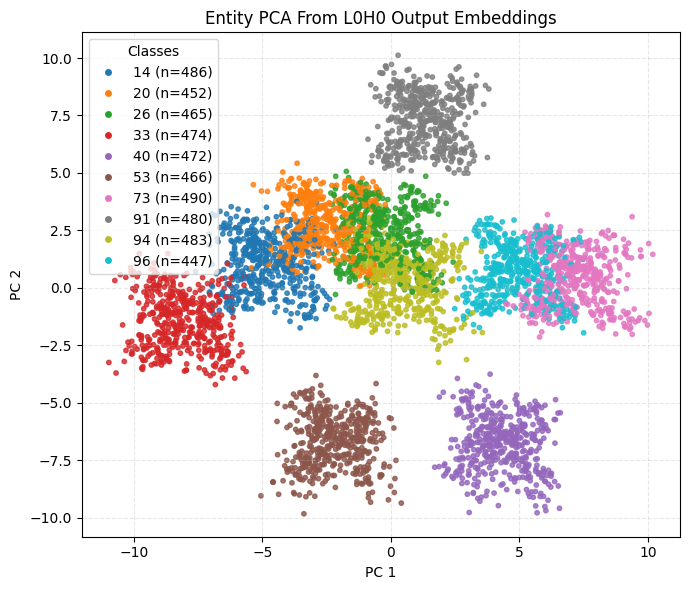

In [112]:
selected = np.random.choice(np.unique(y), size=10, replace=False)
visualize_pca_subset(X, y, classes_to_plot=selected, title="Entity PCA From L0H0 Output Embeddings")

### For Relation at L0H0

In [113]:
X, y = build_probe_dataset(model, test_dataset, hook_name="blocks.0.attn.hook_z", head_idx=0, offset=2)
y -= 100

100%|██████████| 8000/8000 [00:38<00:00, 206.27it/s]


In [114]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

class LinearProbe(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = torch.nn.Linear(128, 10, bias=True) # CHANGE FOR ATTN
    def forward(self, x):
        return self.proj(x)

model2 = LinearProbe()
opt = torch.optim.AdamW(model2.parameters(), lr=1e-2)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 5000

for epoch in range(epochs):
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)
    if epoch % 250 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")
    opt.zero_grad()
    loss.backward()
    opt.step()

model2.eval()
with torch.no_grad():
    logits = model2(X_test)
    pred_idx = logits.argmax(dim=-1)
    acc = (pred_idx == y_test).float().mean().item()

print(f"Accuracy: {acc}")

torch.Size([38209, 128]) torch.Size([9553, 128]) torch.Size([38209]) torch.Size([9553])
Epoch: 0, Loss: 2.3018290996551514
Epoch: 250, Loss: 1.026686668395996
Epoch: 500, Loss: 0.5402655601501465
Epoch: 750, Loss: 0.33953067660331726
Epoch: 1000, Loss: 0.23859861493110657
Epoch: 1250, Loss: 0.17964690923690796
Epoch: 1500, Loss: 0.14152361452579498
Epoch: 1750, Loss: 0.11504888534545898
Epoch: 2000, Loss: 0.0956815704703331
Epoch: 2250, Loss: 0.08094392716884613
Epoch: 2500, Loss: 0.06937897950410843
Epoch: 2750, Loss: 0.06007823720574379
Epoch: 3000, Loss: 0.052447982132434845
Epoch: 3250, Loss: 0.046085018664598465
Epoch: 3500, Loss: 0.04070654883980751
Epoch: 3750, Loss: 0.03610876947641373
Epoch: 4000, Loss: 0.032141271978616714
Epoch: 4250, Loss: 0.02869066409766674
Epoch: 4500, Loss: 0.025669869035482407
Epoch: 4750, Loss: 0.023010846227407455
Accuracy: 1.0


Explained variance ratio: PC1=0.089, PC2=0.080


/var/folders/jd/4hblgkwx24zg166lcr8sj2200000gn/T/ipykernel_74057/3232222326.py:30: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



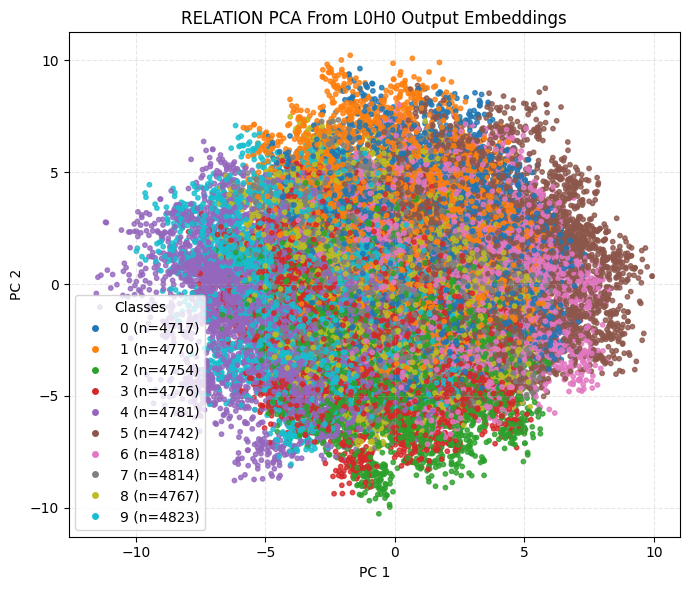

In [115]:
selected = np.random.choice(np.unique(y), size=10, replace=False)
visualize_pca_subset(X, y, classes_to_plot=selected, title="RELATION PCA From L0H0 Output Embeddings")

## Now what about the ? Token - The sort of second part of the circuit that we discovered - it needs to have information about E1 and R

In [116]:
X, y = build_probe_dataset(model, test_dataset, hook_name="blocks.0.attn.hook_z", marker_token=111, head_idx=0, offset=1)

100%|██████████| 8000/8000 [00:36<00:00, 219.28it/s]


In [117]:
X.shape, y.shape

(torch.Size([8000, 128]), torch.Size([8000]))

In [118]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

class LinearProbe(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = torch.nn.Linear(128, 100, bias=True) # CHANGE FOR ATTN
    def forward(self, x):
        return self.proj(x)

model2 = LinearProbe()
opt = torch.optim.AdamW(model2.parameters(), lr=1e-2)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 5000

for epoch in range(epochs):
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)
    if epoch % 250 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")
    opt.zero_grad()
    loss.backward()
    opt.step()

model2.eval()
with torch.no_grad():
    logits = model2(X_test)
    pred_idx = logits.argmax(dim=-1)
    acc = (pred_idx == y_test).float().mean().item()

print(f"Accuracy: {acc}")

torch.Size([6400, 128]) torch.Size([1600, 128]) torch.Size([6400]) torch.Size([1600])
Epoch: 0, Loss: 4.604193210601807
Epoch: 250, Loss: 2.107797384262085
Epoch: 500, Loss: 0.8248782157897949
Epoch: 750, Loss: 0.38195160031318665
Epoch: 1000, Loss: 0.21976177394390106
Epoch: 1250, Loss: 0.1458282619714737
Epoch: 1500, Loss: 0.10578784346580505
Epoch: 1750, Loss: 0.08132340759038925
Epoch: 2000, Loss: 0.0650329664349556
Epoch: 2250, Loss: 0.05347389727830887
Epoch: 2500, Loss: 0.044865697622299194
Epoch: 2750, Loss: 0.03820937126874924
Epoch: 3000, Loss: 0.03290731459856033
Epoch: 3250, Loss: 0.028583098202943802
Epoch: 3500, Loss: 0.024989239871501923
Epoch: 3750, Loss: 0.02195698954164982
Epoch: 4000, Loss: 0.019367564469575882
Epoch: 4250, Loss: 0.017134953290224075
Epoch: 4500, Loss: 0.015195219777524471
Epoch: 4750, Loss: 0.013499702326953411
Accuracy: 1.0


Explained variance ratio: PC1=0.129, PC2=0.114


/var/folders/jd/4hblgkwx24zg166lcr8sj2200000gn/T/ipykernel_74057/3232222326.py:30: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



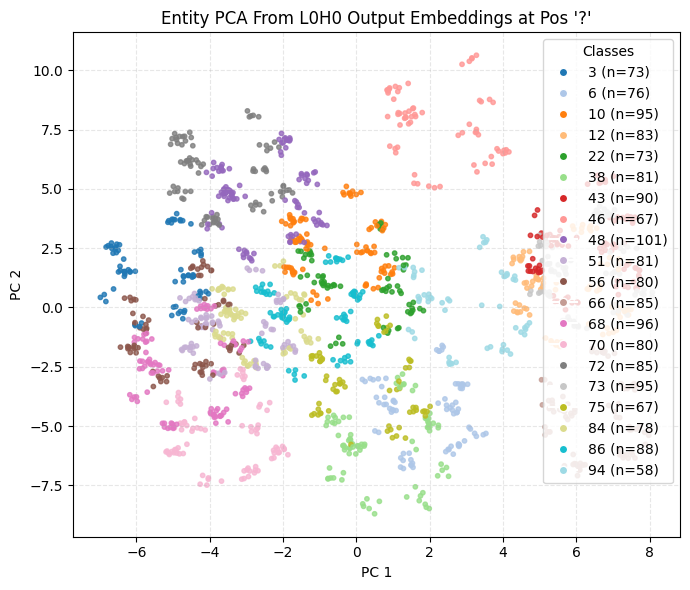

In [119]:
selected = np.random.choice(np.unique(y), size=20, replace=False)
visualize_pca_subset(X, y, classes_to_plot=selected, title="Entity PCA From L0H0 Output Embeddings at Pos '?'")

In [120]:
X, y = build_probe_dataset(model, test_dataset, hook_name="blocks.0.attn.hook_z", marker_token=111, head_idx=0, offset=2)

100%|██████████| 8000/8000 [00:33<00:00, 237.72it/s]


In [121]:
y -= 100

In [122]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

class LinearProbe(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = torch.nn.Linear(128, 10, bias=True) # CHANGE FOR ATTN
    def forward(self, x):
        return self.proj(x)

model2 = LinearProbe()
opt = torch.optim.AdamW(model2.parameters(), lr=1e-2)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 5000

for epoch in range(epochs):
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)
    if epoch % 250 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")
    opt.zero_grad()
    loss.backward()
    opt.step()

model2.eval()
with torch.no_grad():
    logits = model2(X_test)
    pred_idx = logits.argmax(dim=-1)
    acc = (pred_idx == y_test).float().mean().item()

print(f"Accuracy: {acc}")

torch.Size([6400, 128]) torch.Size([1600, 128]) torch.Size([6400]) torch.Size([1600])
Epoch: 0, Loss: 2.3022098541259766
Epoch: 250, Loss: 1.0225601196289062
Epoch: 500, Loss: 0.542668342590332
Epoch: 750, Loss: 0.3440482020378113
Epoch: 1000, Loss: 0.24332641065120697
Epoch: 1250, Loss: 0.18402588367462158
Epoch: 1500, Loss: 0.1454259604215622
Epoch: 1750, Loss: 0.11848149448633194
Epoch: 2000, Loss: 0.09869038313627243
Epoch: 2250, Loss: 0.08358196914196014
Epoch: 2500, Loss: 0.07169599086046219
Epoch: 2750, Loss: 0.06211777776479721
Epoch: 3000, Loss: 0.05424732342362404
Epoch: 3250, Loss: 0.047675784677267075
Epoch: 3500, Loss: 0.042115598917007446
Epoch: 3750, Loss: 0.03735899180173874
Epoch: 4000, Loss: 0.033252228051424026
Epoch: 4250, Loss: 0.029679181054234505
Epoch: 4500, Loss: 0.026550497859716415
Epoch: 4750, Loss: 0.023796193301677704
Accuracy: 1.0


Explained variance ratio: PC1=0.088, PC2=0.079


/var/folders/jd/4hblgkwx24zg166lcr8sj2200000gn/T/ipykernel_74057/3232222326.py:30: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



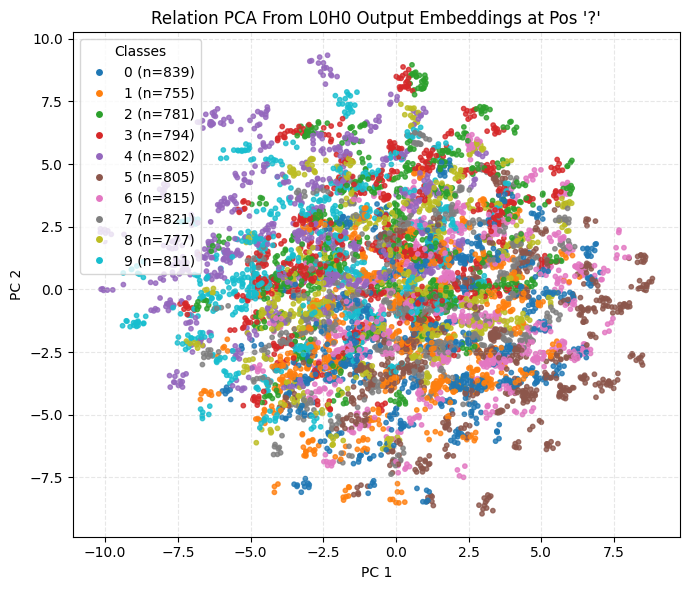

In [123]:
selected = np.random.choice(np.unique(y), size=10, replace=False)
visualize_pca_subset(X, y, classes_to_plot=selected, title="Relation PCA From L0H0 Output Embeddings at Pos '?'")

Hypothesis: At the ? token, L1H0 forms a Query vector Q_? that encodes the query (E_q, T_q). At each comma, L1H0 forms a Key vector K_comma that encodes the identity of that comma's fact, (E1, T). The model has learned projections such that the dot product Q_? · K_correct_comma is very high, and all others are low.

In [124]:
example, label = test_dataset[0]

In [125]:
_, example_cache = model.run_with_cache(example)

In [126]:
example_cache.keys()

dict_keys(['hook_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.attn.hook_q', 'blocks.0.attn.hook_k', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_rot_q', 'blocks.0.attn.hook_rot_k', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern', 'blocks.0.attn.hook_z', 'blocks.0.attn.hook_result', 'blocks.0.hook_attn_out', 'blocks.0.hook_resid_post', 'blocks.1.hook_resid_pre', 'blocks.1.ln1.hook_scale', 'blocks.1.ln1.hook_normalized', 'blocks.1.attn.hook_q', 'blocks.1.attn.hook_k', 'blocks.1.attn.hook_v', 'blocks.1.attn.hook_rot_q', 'blocks.1.attn.hook_rot_k', 'blocks.1.attn.hook_attn_scores', 'blocks.1.attn.hook_pattern', 'blocks.1.attn.hook_z', 'blocks.1.attn.hook_result', 'blocks.1.hook_attn_out', 'blocks.1.hook_resid_post', 'ln_final.hook_scale', 'ln_final.hook_normalized'])

In [127]:
example

tensor([ 10, 104,   1, 110,  20, 103,  30, 110,  70, 105,  37, 110,  30, 100,
         24, 110, 105,  70, 111])

In [128]:
comma_positions = [3,7,11,15]

In [129]:
l1h0_q = example_cache['blocks.1.attn.hook_q'][0, -1, 0, :]

In [130]:
commas = [example_cache['blocks.1.attn.hook_k'][0, comma_pos, 0, :] for comma_pos in comma_positions]

In [131]:
for i, c in enumerate(commas):
    print(f"idx {i} dot product {l1h0_q @ c}")

idx 0 dot product 19.75131607055664
idx 1 dot product 69.32681274414062
idx 2 dot product 181.07887268066406
idx 3 dot product 81.63691711425781


In [132]:
l1h1_q = example_cache['blocks.1.attn.hook_q'][0, -1, 1, :]
commas = [example_cache['blocks.1.attn.hook_k'][0, comma_pos, 1, :] for comma_pos in comma_positions]
for i, c in enumerate(commas):
    print(f"idx {i} dot product {l1h1_q @ c}")

idx 0 dot product 26.763158798217773
idx 1 dot product 74.35011291503906
idx 2 dot product 183.42034912109375
idx 3 dot product 81.5477523803711


In [133]:
for i, c in enumerate(commas):
    print(f"idx {i} dot product {l1h0_q @ c}")

idx 0 dot product -3.993412494659424
idx 1 dot product -7.224828720092773
idx 2 dot product -4.505153656005859
idx 3 dot product -8.655160903930664


In [ ]:
## Doing it over all examples

In [134]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


@torch.no_grad()
def analyze_l1_qk_matching(model, dataset, query_token=111, comma_token=110):
    device = next(model.parameters()).device
    hook_names = {"blocks.1.attn.hook_q", "blocks.1.attn.hook_k"}
    pair_order = [(0, 0), (1, 1), (0, 1), (1, 0)]  # (q_head, k_head)

    pair_stats = {pair: {"top1": [], "rank": [], "margin": []} for pair in pair_order}
    details = []

    for ds_idx in tqdm(range(len(dataset))):
        tokens, label = dataset[ds_idx]
        tokens = tokens.to(device)

        q_poss = (tokens == query_token).nonzero(as_tuple=False)
        if q_poss.numel() != 1:
            continue
        q_pos = int(q_poss.item())

        comma_positions = (tokens == comma_token).nonzero(as_tuple=False).flatten().tolist()
        if len(comma_positions) == 0:
            continue

        query_e1 = int(tokens[q_pos - 1].item())
        query_t = int(tokens[q_pos - 2].item())

        facts = []
        for p in comma_positions:
            facts.append(
                (
                    int(tokens[p - 3].item()),  # E1
                    int(tokens[p - 2].item()),  # T
                    int(tokens[p - 1].item()),  # E2
                )
            )

        correct_idx = next(
            (i for i, (e1, t, e2) in enumerate(facts) if e1 == query_e1 and t == query_t),
            None,
        )
        if correct_idx is None:
            continue

        _, cache = model.run_with_cache(
            tokens.unsqueeze(0),
            names_filter=lambda name: name in hook_names,
        )

        q_all = cache["blocks.1.attn.hook_q"][0, q_pos]  # [head, d_head]
        k_all = cache["blocks.1.attn.hook_k"][0, comma_positions]  # [n_commas, head, d_head]

        row = {
            "ds_idx": ds_idx,
            "query": (query_e1, query_t),
            "facts": facts,
            "comma_positions": comma_positions,
            "correct_idx": correct_idx,
            "correct_comma_pos": comma_positions[correct_idx],
            "label": int(label.item()),
        }

        for q_head, k_head in pair_order:
            scores = (k_all[:, k_head, :] @ q_all[q_head, :]).float().detach().cpu()
            correct_score = scores[correct_idx].item()

            if len(scores) == 1:
                best_incorrect = float("-inf")
                margin = float("inf")
                top1 = True
                rank = 1
            else:
                mask = torch.ones(len(scores), dtype=torch.bool)
                mask[correct_idx] = False
                best_incorrect = scores[mask].max().item()
                margin = correct_score - best_incorrect
                top1 = bool(scores.argmax().item() == correct_idx)
                rank = int((scores > correct_score).sum().item()) + 1

            pair_stats[(q_head, k_head)]["top1"].append(float(top1))
            pair_stats[(q_head, k_head)]["rank"].append(rank)
            pair_stats[(q_head, k_head)]["margin"].append(margin)

            row[f"scores_q{q_head}_k{k_head}"] = scores.tolist()
            row[f"top1_q{q_head}_k{k_head}"] = top1
            row[f"margin_q{q_head}_k{k_head}"] = margin
            row[f"rank_q{q_head}_k{k_head}"] = rank

        details.append(row)
        del cache

    return {
        "pair_stats": pair_stats,
        "details": details,
        "pair_order": pair_order,
    }


In [140]:
results_qk = analyze_l1_qk_matching(model, test_dataset)


100%|██████████| 8000/8000 [00:35<00:00, 222.63it/s]


Layer 1 query-key matching summary

Q0-K0: top1=1.000, mean_rank=1.000, mean_margin=103.200, median_margin=102.919
Q1-K1: top1=1.000, mean_rank=1.000, mean_margin=102.480, median_margin=102.361
Q0-K1: top1=0.139, mean_rank=3.740, mean_margin=-25.002, median_margin=-24.356
Q1-K0: top1=0.156, mean_rank=3.653, mean_margin=-22.154, median_margin=-20.938
[1.0, 1.0, 0.139125, 0.15575]


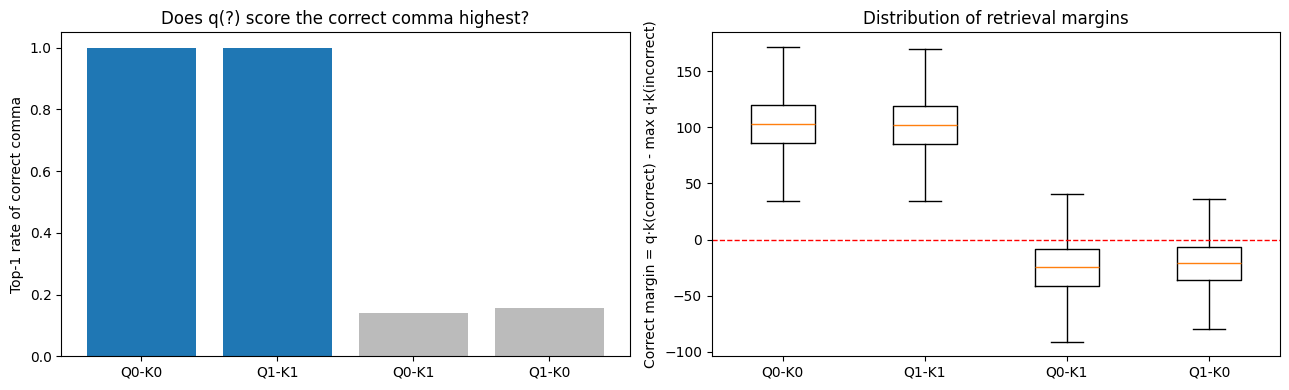

In [141]:
results = results_qk
pair_order = results["pair_order"]
label_map = {
    (0, 0): "Q0-K0",
    (1, 1): "Q1-K1",
    (0, 1): "Q0-K1",
    (1, 0): "Q1-K0",
}

print("Layer 1 query-key matching summary\n")
for pair in pair_order:
    stats = results["pair_stats"][pair]
    top1 = np.mean(stats["top1"])
    mean_rank = np.mean(stats["rank"])
    mean_margin = np.mean(stats["margin"])
    median_margin = np.median(stats["margin"])
    print(
        f"{label_map[pair]}: "
        f"top1={top1:.3f}, "
        f"mean_rank={mean_rank:.3f}, "
        f"mean_margin={mean_margin:.3f}, "
        f"median_margin={median_margin:.3f}"
    )

labels = [label_map[p] for p in pair_order]
top1_rates = [np.mean(results["pair_stats"][p]["top1"]) for p in pair_order]
print(top1_rates)
margins = [results["pair_stats"][p]["margin"] for p in pair_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ["#1f77b4", "#1f77b4", "#bbbbbb", "#bbbbbb"]

axes[0].bar(labels, top1_rates, color=colors)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Top-1 rate of correct comma")
axes[0].set_title("Does q(?) score the correct comma highest?")

axes[1].boxplot(margins, tick_labels=labels, showfliers=False)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_ylabel("Correct margin = q·k(correct) - max q·k(incorrect)")
axes[1].set_title("Distribution of retrieval margins")

plt.tight_layout()
plt.show()


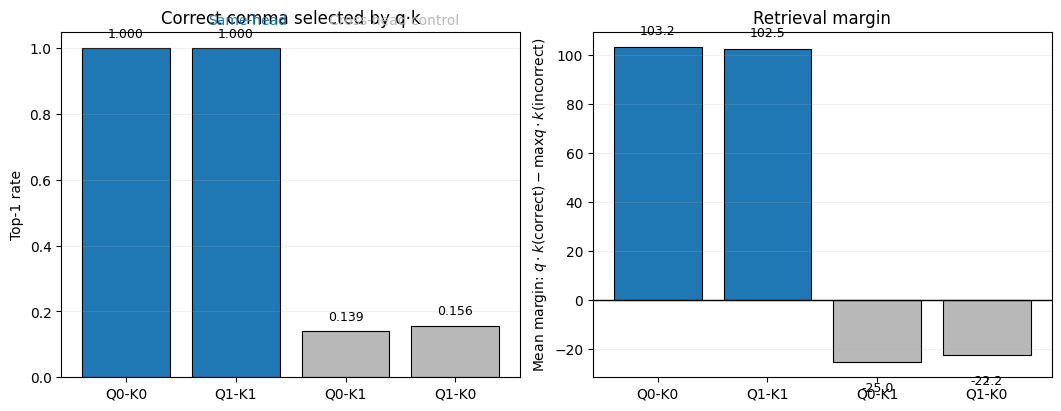

In [149]:
import numpy as np
import matplotlib.pyplot as plt

results = results_qk
pair_order = results["pair_order"]

label_map = {
    (0, 0): "Q0-K0",
    (1, 1): "Q1-K1",
    (0, 1): "Q0-K1",
    (1, 0): "Q1-K0",
}

labels = [label_map[p] for p in pair_order]
top1_rates = [np.mean(results["pair_stats"][p]["top1"]) for p in pair_order]
mean_margins = [np.mean(results["pair_stats"][p]["margin"]) for p in pair_order]
std_margins = [np.std(results["pair_stats"][p]["margin"]) for p in pair_order]

same_head_color = "#1f77b4"
cross_head_color = "#b8b8b8"
colors = [same_head_color, same_head_color, cross_head_color, cross_head_color]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), constrained_layout=True)

# Left panel: top-1 retrieval rate
axes[0].bar(labels, top1_rates, color=colors, edgecolor="black", linewidth=0.8)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Top-1 rate")
axes[0].set_title("Correct comma selected by q·k")
axes[0].grid(axis="y", alpha=0.2)

for i, v in enumerate(top1_rates):
    axes[0].text(i, v + 0.025, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

# Right panel: mean retrieval margin
axes[1].bar(labels, mean_margins, color=colors, edgecolor="black", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel(r"Mean margin: $q\cdot k(\mathrm{correct}) - \max q\cdot k(\mathrm{incorrect})$")
axes[1].set_title("Retrieval margin")
axes[1].grid(axis="y", alpha=0.2)

for i, v in enumerate(mean_margins):
    y = v + 4 if v >= 0 else v - 8
    axes[1].text(i, y, f"{v:.1f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)

# Small legend-like annotation
fig.text(0.23, 0.98, "Same-head", color=same_head_color, fontsize=10, ha="center", va="top")
fig.text(
    0.37, 0.98, "Cross-head control", color=cross_head_color, fontsize=10, ha="center", va="top"
)

plt.show()


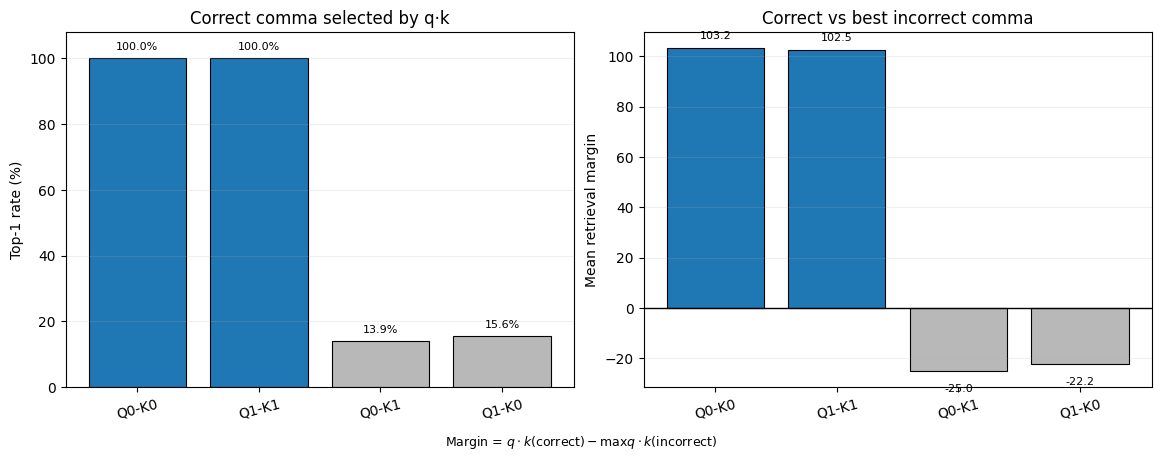

In [150]:
import numpy as np
import matplotlib.pyplot as plt

results = results_qk
pair_order = results["pair_order"]

label_map = {
    (0, 0): "Q0-K0",
    (1, 1): "Q1-K1",
    (0, 1): "Q0-K1",
    (1, 0): "Q1-K0",
}

labels = [label_map[p] for p in pair_order]
top1_rates = [100 * np.mean(results["pair_stats"][p]["top1"]) for p in pair_order]
mean_margins = [np.mean(results["pair_stats"][p]["margin"]) for p in pair_order]

same_head_color = "#1f77b4"
cross_head_color = "#b8b8b8"
colors = [same_head_color, same_head_color, cross_head_color, cross_head_color]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)

# Left panel: Top-1 rate in %
axes[0].bar(labels, top1_rates, color=colors, edgecolor="black", linewidth=0.8)
axes[0].set_ylim(0, 108)
axes[0].set_ylabel("Top-1 rate (%)")
axes[0].set_title("Correct comma selected by q·k", fontsize=12)
axes[0].grid(axis="y", alpha=0.2)
axes[0].tick_params(axis="x", labelrotation=15)

for i, v in enumerate(top1_rates):
    axes[0].text(i, v + 2, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

# Right panel: Mean retrieval margin
axes[1].bar(labels, mean_margins, color=colors, edgecolor="black", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("Mean retrieval margin")
axes[1].set_title("Correct vs best incorrect comma", fontsize=12)
axes[1].grid(axis="y", alpha=0.2)
axes[1].tick_params(axis="x", labelrotation=15)

for i, v in enumerate(mean_margins):
    offset = 3 if v >= 0 else -5
    axes[1].text(
        i,
        v + offset,
        f"{v:.1f}",
        ha="center",
        va="bottom" if v >= 0 else "top",
        fontsize=8,
    )

fig.text(
    0.5,
    -0.02,
    r"Margin = $q \cdot k(\mathrm{correct}) - \max q \cdot k(\mathrm{incorrect})$",
    ha="center",
    va="top",
    fontsize=9,
)

plt.show()


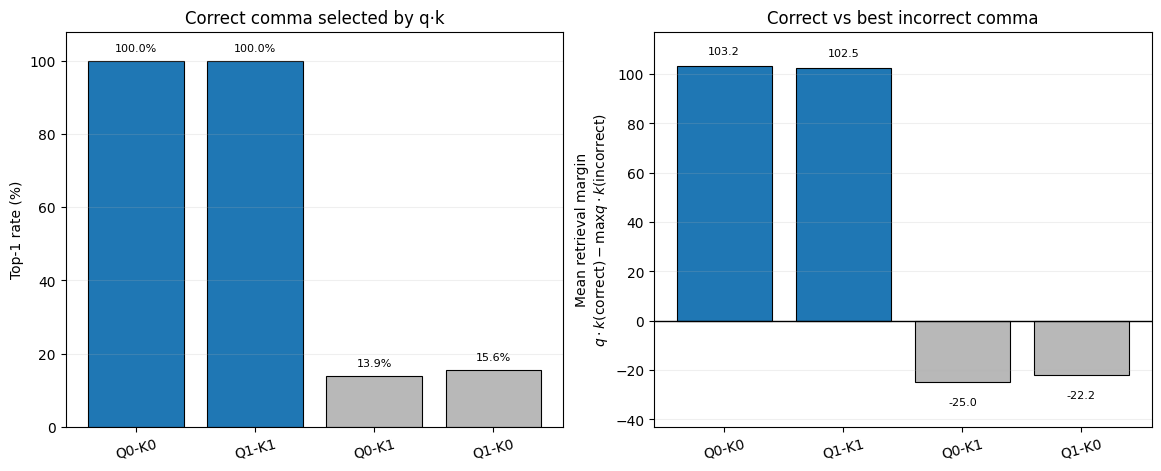

In [153]:
import numpy as np
import matplotlib.pyplot as plt

results = results_qk
pair_order = results["pair_order"]

label_map = {
    (0, 0): "Q0-K0",
    (1, 1): "Q1-K1",
    (0, 1): "Q0-K1",
    (1, 0): "Q1-K0",
}

labels = [label_map[p] for p in pair_order]
top1_rates = [100 * np.mean(results["pair_stats"][p]["top1"]) for p in pair_order]
mean_margins = [np.mean(results["pair_stats"][p]["margin"]) for p in pair_order]

same_head_color = "#1f77b4"
cross_head_color = "#b8b8b8"
colors = [same_head_color, same_head_color, cross_head_color, cross_head_color]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)

# Left panel
axes[0].bar(labels, top1_rates, color=colors, edgecolor="black", linewidth=0.8)
axes[0].set_ylim(0, 108)
axes[0].set_ylabel("Top-1 rate (%)")
axes[0].set_title("Correct comma selected by q·k", fontsize=12)
axes[0].grid(axis="y", alpha=0.2)
axes[0].tick_params(axis="x", labelrotation=15)

for i, v in enumerate(top1_rates):
    axes[0].text(i, v + 2, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

# Right panel
axes[1].bar(labels, mean_margins, color=colors, edgecolor="black", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel(
    "Mean retrieval margin\n$q \\cdot k(\\mathrm{correct}) - \\max q \\cdot k(\\mathrm{incorrect})$"
)

axes[1].set_title("Correct vs best incorrect comma", fontsize=12)
axes[1].grid(axis="y", alpha=0.2)
axes[1].tick_params(axis="x", labelrotation=15)

ymin = min(mean_margins)
ymax = max(mean_margins)
axes[1].set_ylim(ymin - 18, ymax + 14)

for i, v in enumerate(mean_margins):
    offset = 4 if v >= 0 else -6
    axes[1].text(
        i,
        v + offset,
        f"{v:.1f}",
        ha="center",
        va="bottom" if v >= 0 else "top",
        fontsize=8,
    )
plt.savefig("l1_qk_matching_results.png", dpi=300)
plt.show()
